In [49]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [50]:
# read data disease_area
txgnn_results = pd.read_csv("/home/bbc8731/BioMedFormer/data/TxGNN_results/result_more_metrics.csv")

In [51]:
# autoimmune
####### read netmedgpt results:
plot_dir = "/home/bbc8731/BioMedFormer/data/plot/disease_area"
data_dir_disease_area = "/home/bbc8731/BioMedFormer/data/result/disease_area/"
data_dir_autoimmune = os.path.join(data_dir_disease_area, "biomedformer_atr_v2_autoimmune_['indication', 'contraindication']_inductive_wl5_wpn30_dim300_head5_lencoder30_bs4000_lr0.0001_20250803_171225")

#### indication
# AUC
Lp_test_autoimmune = pd.read_csv(os.path.join(data_dir_autoimmune, "LP_test.csv"))
Lp_test_indication_autoimmune = Lp_test_autoimmune.iloc[::2]
indication_aucs_autoimmune = Lp_test_indication_autoimmune['auc']
mean_indication_aucs_autoimmune = round(indication_aucs_autoimmune.mean(), 2)
std_indication_aucs_autoimmune = round(indication_aucs_autoimmune.std(), 2)
# recall@100
recall_precision_autoimmune = pd.read_csv(os.path.join(data_dir_autoimmune, "hit_precision_test.csv"))
recall_precision_indication_autoimmune = recall_precision_autoimmune.iloc[::2]
indication_recall_autoimmune = recall_precision_indication_autoimmune['hit']
mean_indication_recall_autoimmune = round(indication_recall_autoimmune.mean(), 2)
std_indication_recall_autoimmune = round(indication_recall_autoimmune.std(), 2)

#### contraindication
# AUC
Lp_test_contraindication_autoimmune = Lp_test_autoimmune.iloc[1::2]
contraindication_aucs_autoimmune = Lp_test_contraindication_autoimmune['auc']
mean_contraindication_aucs_autoimmune = round(contraindication_aucs_autoimmune.mean(), 2)
std_contraindication_aucs_autoimmune = round(contraindication_aucs_autoimmune.std(), 2)
# recall@100
recall_precision_contraindication_autoimmune = recall_precision_autoimmune.iloc[1::2]
contraindication_recall_autoimmune = recall_precision_contraindication_autoimmune['hit']
mean_contraindication_recall_autoimmune = round(contraindication_recall_autoimmune.mean(), 2)
std_contraindication_recall_autoimmune = round(contraindication_recall_autoimmune.std(), 2)
####################################################################################################
# read other methods
txgnn_autoimmune = txgnn_results.loc[txgnn_results['Split'] == 'autoimmune',:]

indication_rows = []
contraindication_rows = []

for i in txgnn_autoimmune['Metric Name'].unique():
    metric_i = txgnn_autoimmune.loc[txgnn_autoimmune['Metric Name'] == i,:]

    for j in metric_i['Method'].unique():
        method_j = metric_i.loc[metric_i['Method'] == j,:]

        indi = method_j.loc[method_j['Task'] == 'indication', 'Metric']
        contra = method_j.loc[method_j['Task'] == 'contraindication', 'Metric']

        mean_indication = np.nanmean(indi) if not indi.empty else np.nan
        std_indication = np.nanstd(indi) if not indi.empty else np.nan
        indication_rows.append([j, i, mean_indication, std_indication])

        mean_contraindication = np.nanmean(contra) if not contra.empty else np.nan
        std_contraindication  = np.nanstd(contra)  if not contra.empty else np.nan
        contraindication_rows.append([j, i, mean_contraindication, std_contraindication])

# build final DataFrames
indication_autoimmune = pd.DataFrame(indication_rows, columns=['method','Metric','mean','std'])
contraindication_autoimmune = pd.DataFrame(contraindication_rows, columns=['method','Metric','mean','std'])

##############################################################################
# other methods
############# indication
### Compute AUC 
indication_aucs_other = indication_autoimmune.loc[indication_autoimmune['Metric'] == 'AUROC',:]

# NetMedGPT results
new_row = pd.DataFrame(
    [['NetMedGPT', 'AUROC', mean_indication_aucs_autoimmune, std_indication_aucs_autoimmune]],
    columns=['method','Metric','mean','std']
)
indication_aucs_autoimmune = pd.concat([indication_aucs_other, new_row], ignore_index=True)


##############################################################################
### Compute Recall@100 
indication_recall100_other = indication_autoimmune.loc[indication_autoimmune['Metric'] == 'Recall@100',:]

new_row = pd.DataFrame(
    [['NetMedGPT', 'Recall@100', mean_indication_recall_autoimmune, std_indication_recall_autoimmune]],
    columns=['method','Metric','mean','std']
)
indication_recall100_autoimmune = pd.concat([indication_recall100_other, new_row], ignore_index=True)

############### contraindication
### Compute AUC 
contraindication_aucs_other = contraindication_autoimmune.loc[contraindication_autoimmune['Metric'] == 'AUROC',:]
new_row = pd.DataFrame(
    [['NetMedGPT', 'AUROC', mean_contraindication_aucs_autoimmune, std_contraindication_aucs_autoimmune]],
    columns=['method','Metric','mean','std']
)
contraindication_aucs_autoimmune = pd.concat([contraindication_aucs_other, new_row], ignore_index=True)

#############################################################################
### Compute Recall@100 
contraindication_recall100_other = contraindication_autoimmune.loc[contraindication_autoimmune['Metric'] == 'Recall@100',:]

new_row = pd.DataFrame(
    [['NetMedGPT', 'Recall@100', mean_contraindication_recall_autoimmune, std_contraindication_recall_autoimmune]],
    columns=['method','Metric','mean','std']
)
contraindication_recall100_autoimmune = pd.concat([contraindication_recall100_other, new_row], ignore_index=True)

indication_recall100_autoimmune

,method,Metric,mean,std
0,DSD-min,Recall@100,0.008351,8.148078e-03
1,KL-min,Recall@100,0.022337,3.708978e-02
2,JS-min,Recall@100,0.004602,3.878470e-03
3,HGT,Recall@100,0.002797,3.425860e-03
4,HAN,Recall@100,0.090089,6.162339e-02
5,RGCN,Recall@100,0.038462,0.000000e+00
6,BioBERT,Recall@100,0.029586,3.469447e-18
7,TxGNN,Recall@100,0.337641,3.846154e-03
8,Proximity,Recall@100,0.008176,2.366864e-03
9,NetMedGPT,Recall@100,0.690000,7.000000e-02


In [52]:
# metabolic_disorder
####### read netmedgpt results:
plot_dir = "/home/bbc8731/BioMedFormer/data/plot/disease_area"
data_dir_disease_area = "/home/bbc8731/BioMedFormer/data/result/disease_area/"
data_dir_metabolic_disorder = os.path.join(data_dir_disease_area, "biomedformer_atr_v2_metabolic_disorder_['indication', 'contraindication']_inductive_wl5_wpn30_dim300_head5_lencoder30_bs4000_lr0.0001_20250811_173629")

#### indication
# AUC
Lp_test_metabolic_disorder = pd.read_csv(os.path.join(data_dir_metabolic_disorder, "LP_test.csv"))
Lp_test_indication_metabolic_disorder = Lp_test_metabolic_disorder.iloc[::2]
indication_aucs_metabolic_disorder = Lp_test_indication_metabolic_disorder['auc']
mean_indication_aucs_metabolic_disorder = round(indication_aucs_metabolic_disorder.mean(), 2)
std_indication_aucs_metabolic_disorder = round(indication_aucs_metabolic_disorder.std(), 2)
# recall@100
recall_precision_metabolic_disorder = pd.read_csv(os.path.join(data_dir_metabolic_disorder, "hit_precision_test.csv"))
recall_precision_indication_metabolic_disorder = recall_precision_metabolic_disorder.iloc[::2]
indication_recall_metabolic_disorder = recall_precision_indication_metabolic_disorder['hit']
mean_indication_recall_metabolic_disorder = round(indication_recall_metabolic_disorder.mean(), 2)
std_indication_recall_metabolic_disorder = round(indication_recall_metabolic_disorder.std(), 2)

#### contraindication
# AUC
Lp_test_contraindication_metabolic_disorder = Lp_test_metabolic_disorder.iloc[1::2]
contraindication_aucs_metabolic_disorder = Lp_test_contraindication_metabolic_disorder['auc']
mean_contraindication_aucs_metabolic_disorder = round(contraindication_aucs_metabolic_disorder.mean(), 2)
std_contraindication_aucs_metabolic_disorder = round(contraindication_aucs_metabolic_disorder.std(), 2)
# recall@100
recall_precision_contraindication_metabolic_disorder = recall_precision_metabolic_disorder.iloc[1::2]
contraindication_recall_metabolic_disorder = recall_precision_contraindication_metabolic_disorder['hit']
mean_contraindication_recall_metabolic_disorder = round(contraindication_recall_metabolic_disorder.mean(), 2)
std_contraindication_recall_metabolic_disorder = round(contraindication_recall_metabolic_disorder.std(), 2)
####################################################################################################
# read other methods
txgnn_metabolic_disorder = txgnn_results.loc[txgnn_results['Split'] == 'metabolic_disorder',:]

indication_rows = []
contraindication_rows = []

for i in txgnn_metabolic_disorder['Metric Name'].unique():
    metric_i = txgnn_metabolic_disorder.loc[txgnn_metabolic_disorder['Metric Name'] == i,:]

    for j in metric_i['Method'].unique():
        method_j = metric_i.loc[metric_i['Method'] == j,:]

        indi = method_j.loc[method_j['Task'] == 'indication', 'Metric']
        contra = method_j.loc[method_j['Task'] == 'contraindication', 'Metric']

        mean_indication = np.nanmean(indi) if not indi.empty else np.nan
        std_indication = np.nanstd(indi) if not indi.empty else np.nan
        indication_rows.append([j, i, mean_indication, std_indication])

        mean_contraindication = np.nanmean(contra) if not contra.empty else np.nan
        std_contraindication  = np.nanstd(contra)  if not contra.empty else np.nan
        contraindication_rows.append([j, i, mean_contraindication, std_contraindication])

# build final DataFrames
indication_metabolic_disorder = pd.DataFrame(indication_rows, columns=['method','Metric','mean','std'])
contraindication_metabolic_disorder = pd.DataFrame(contraindication_rows, columns=['method','Metric','mean','std'])

##############################################################################
# other methods
## indication
####### Compute AUC 
indication_aucs_other = indication_metabolic_disorder.loc[indication_metabolic_disorder['Metric'] == 'AUROC',:]

# NetMedGPT results
new_row = pd.DataFrame(
    [['NetMedGPT', 'AUROC', mean_indication_aucs_metabolic_disorder, std_indication_aucs_metabolic_disorder]],
    columns=['method','Metric','mean','std']
)
indication_aucs_metabolic_disorder = pd.concat([indication_aucs_other, new_row], ignore_index=True)

##############################################################################
####### Compute Recall@100 
indication_recall100_other = indication_metabolic_disorder.loc[indication_metabolic_disorder['Metric'] == 'Recall@100',:]

new_row = pd.DataFrame(
    [['NetMedGPT', 'Recall@100', mean_indication_recall_metabolic_disorder, std_indication_recall_metabolic_disorder]],
    columns=['method','Metric','mean','std']
)
indication_recall100_metabolic_disorder = pd.concat([indication_recall100_other, new_row], ignore_index=True)

###############
# contraindication
####### Compute AUC 
contraindication_aucs_other = contraindication_metabolic_disorder.loc[contraindication_metabolic_disorder['Metric'] == 'AUROC',:]

new_row = pd.DataFrame(
    [['NetMedGPT', 'AUROC', mean_contraindication_aucs_metabolic_disorder, std_contraindication_aucs_metabolic_disorder]],
    columns=['method','Metric','mean','std']
)
contraindication_aucs_metabolic_disorder = pd.concat([contraindication_aucs_other, new_row], ignore_index=True)

#############################################################################
####### Compute Recall@100 
contraindication_recall100_other = contraindication_metabolic_disorder.loc[contraindication_metabolic_disorder['Metric'] == 'Recall@100',:]

new_row = pd.DataFrame(
    [['NetMedGPT', 'Recall@100', mean_contraindication_recall_metabolic_disorder, std_contraindication_recall_metabolic_disorder]],
    columns=['method','Metric','mean','std']
)
contraindication_recall100_metabolic_disorder = pd.concat([contraindication_recall100_other, new_row], ignore_index=True)

indication_recall100_metabolic_disorder

,method,Metric,mean,std
0,DSD-min,Recall@100,0.019354,0.020059
1,KL-min,Recall@100,0.007925,0.008135
2,JS-min,Recall@100,0.015306,0.017747
3,HGT,Recall@100,0.032381,0.028276
4,HAN,Recall@100,0.035476,0.056807
5,RGCN,Recall@100,0.221429,0.034993
6,BioBERT,Recall@100,0.017857,0.000000
7,TxGNN,Recall@100,0.212959,0.033424
8,Proximity,Recall@100,0.000000,0.000000
9,NetMedGPT,Recall@100,0.570000,0.080000


In [53]:
# diabetes
####### read netmedgpt results:
plot_dir = "/home/bbc8731/BioMedFormer/data/plot/disease_area"
data_dir_disease_area = "/home/bbc8731/BioMedFormer/data/result/disease_area/"
data_dir_diabetes = os.path.join(data_dir_disease_area, "biomedformer_atr_v2_diabetes_['indication', 'contraindication']_inductive_wl5_wpn30_dim300_head5_lencoder30_bs4000_lr0.0001_20250807_104629")

#### indication
# AUC
Lp_test_diabetes = pd.read_csv(os.path.join(data_dir_diabetes, "LP_test.csv"))
Lp_test_indication_diabetes = Lp_test_diabetes.iloc[::2]
indication_aucs_diabetes = Lp_test_indication_diabetes['auc']
mean_indication_aucs_diabetes = round(indication_aucs_diabetes.mean(), 2)
std_indication_aucs_diabetes = round(indication_aucs_diabetes.std(), 2)
# recall@100
recall_precision_diabetes = pd.read_csv(os.path.join(data_dir_diabetes, "hit_precision_test.csv"))
recall_precision_indication_diabetes = recall_precision_diabetes.iloc[::2]
indication_recall_diabetes = recall_precision_indication_diabetes['hit']
mean_indication_recall_diabetes = round(indication_recall_diabetes.mean(), 2)
std_indication_recall_diabetes = round(indication_recall_diabetes.std(), 2)

#### contraindication
# AUC
Lp_test_contraindication_diabetes = Lp_test_diabetes.iloc[1::2]
contraindication_aucs_diabetes = Lp_test_contraindication_diabetes['auc']
mean_contraindication_aucs_diabetes = round(contraindication_aucs_diabetes.mean(), 2)
std_contraindication_aucs_diabetes = round(contraindication_aucs_diabetes.std(), 2)
# recall@100
recall_precision_contraindication_diabetes = recall_precision_diabetes.iloc[1::2]
contraindication_recall_diabetes = recall_precision_contraindication_diabetes['hit']
mean_contraindication_recall_diabetes = round(contraindication_recall_diabetes.mean(), 2)
std_contraindication_recall_diabetes = round(contraindication_recall_diabetes.std(), 2)
####################################################################################################
# read other methods
txgnn_diabetes = txgnn_results.loc[txgnn_results['Split'] == 'diabetes',:]

indication_rows = []
contraindication_rows = []

for i in txgnn_diabetes['Metric Name'].unique():
    metric_i = txgnn_diabetes.loc[txgnn_diabetes['Metric Name'] == i,:]

    for j in metric_i['Method'].unique():
        method_j = metric_i.loc[metric_i['Method'] == j,:]

        indi = method_j.loc[method_j['Task'] == 'indication', 'Metric']
        contra = method_j.loc[method_j['Task'] == 'contraindication', 'Metric']

        mean_indication = np.nanmean(indi) if not indi.empty else np.nan
        std_indication = np.nanstd(indi) if not indi.empty else np.nan
        indication_rows.append([j, i, mean_indication, std_indication])

        mean_contraindication = np.nanmean(contra) if not contra.empty else np.nan
        std_contraindication  = np.nanstd(contra)  if not contra.empty else np.nan
        contraindication_rows.append([j, i, mean_contraindication, std_contraindication])

# build final DataFrames
indication_diabetes = pd.DataFrame(indication_rows, columns=['method','Metric','mean','std'])
contraindication_diabetes = pd.DataFrame(contraindication_rows, columns=['method','Metric','mean','std'])

##############################################################################
###############
# other methods
## indication
####### Compute AUC 
indication_aucs_other_diabetes = indication_diabetes.loc[indication_diabetes['Metric'] == 'AUROC',:]

# NetMedGPT results
new_row = pd.DataFrame(
    [['NetMedGPT', 'AUROC', mean_indication_aucs_diabetes, std_indication_aucs_diabetes]],
    columns=['method','Metric','mean','std']
)
indication_aucs_diabetes = pd.concat([indication_aucs_other_diabetes, new_row], ignore_index=True)

####### Compute Recall@100 
indication_recall100_other = indication_diabetes.loc[indication_diabetes['Metric'] == 'Recall@100',:]

new_row = pd.DataFrame(
    [['NetMedGPT', 'Recall@100', mean_indication_recall_diabetes, std_indication_recall_diabetes]],
    columns=['method','Metric','mean','std']
)
indication_recall100_diabetes = pd.concat([indication_recall100_other, new_row], ignore_index=True)

##############################################################################
# contraindication
####### Compute AUC 
contraindication_aucs_other_diabetes = contraindication_diabetes.loc[contraindication_diabetes['Metric'] == 'AUROC',:]

new_row = pd.DataFrame(
    [['NetMedGPT', 'AUROC', mean_contraindication_aucs_diabetes, std_contraindication_aucs_diabetes]],
    columns=['method','Metric','mean','std']
)
contraindication_aucs_diabetes = pd.concat([contraindication_aucs_other_diabetes, new_row], ignore_index=True)


####### Compute Recall@100 
contraindication_recall100_other = contraindication_diabetes.loc[contraindication_diabetes['Metric'] == 'Recall@100',:]

new_row = pd.DataFrame(
    [['NetMedGPT', 'Recall@100', mean_contraindication_recall_diabetes, std_contraindication_recall_diabetes]],
    columns=['method','Metric','mean','std']
)
contraindication_recall100_diabetes = pd.concat([contraindication_recall100_other, new_row], ignore_index=True)

indication_recall100_diabetes

,method,Metric,mean,std
0,DSD-min,Recall@100,0.011783,0.009783
1,KL-min,Recall@100,0.013516,0.004699
2,JS-min,Recall@100,0.020100,0.016801
3,HGT,Recall@100,0.005968,0.008092
4,HAN,Recall@100,0.000000,0.000000
5,RGCN,Recall@100,0.000000,0.000000
6,BioBERT,Recall@100,0.018868,0.000000
7,TxGNN,Recall@100,0.235657,0.000000
8,Proximity,Recall@100,0.023566,0.007855
9,NetMedGPT,Recall@100,0.110000,0.040000


In [54]:
# neurodigenerative
####### read netmedgpt results:
plot_dir = "/home/bbc8731/BioMedFormer/data/plot/disease_area"
data_dir_disease_area = "/home/bbc8731/BioMedFormer/data/result/disease_area/"
data_dir_neurodigenerative = os.path.join(data_dir_disease_area, "biomedformer_atr_v2_neurodigenerative_['indication', 'contraindication']_inductive_wl5_wpn30_dim300_head5_lencoder30_bs4000_lr0.0001_20250811_231544")

#### indication
# AUC
Lp_test_neurodigenerative = pd.read_csv(os.path.join(data_dir_neurodigenerative, "LP_test.csv"))
Lp_test_indication_neurodigenerative = Lp_test_neurodigenerative.iloc[::2]
indication_aucs_neurodigenerative = Lp_test_indication_neurodigenerative['auc']
mean_indication_aucs_neurodigenerative = round(indication_aucs_neurodigenerative.mean(), 2)
std_indication_aucs_neurodigenerative = round(indication_aucs_neurodigenerative.std(), 2)
# recall@100
recall_precision_neurodigenerative = pd.read_csv(os.path.join(data_dir_neurodigenerative, "hit_precision_test.csv"))
recall_precision_indication_neurodigenerative = recall_precision_neurodigenerative.iloc[::2]
indication_recall_neurodigenerative = recall_precision_indication_neurodigenerative['hit']
mean_indication_recall_neurodigenerative = round(indication_recall_neurodigenerative.mean(), 2)
std_indication_recall_neurodigenerative = round(indication_recall_neurodigenerative.std(), 2)

#### contraindication
# AUC
Lp_test_contraindication_neurodigenerative = Lp_test_neurodigenerative.iloc[1::2]
contraindication_aucs_neurodigenerative = Lp_test_contraindication_neurodigenerative['auc']
mean_contraindication_aucs_neurodigenerative = round(contraindication_aucs_neurodigenerative.mean(), 2)
std_contraindication_aucs_neurodigenerative = round(contraindication_aucs_neurodigenerative.std(), 2)
# recall@100
recall_precision_contraindication_neurodigenerative = recall_precision_neurodigenerative.iloc[1::2]
contraindication_recall_neurodigenerative = recall_precision_contraindication_neurodigenerative['hit']
mean_contraindication_recall_neurodigenerative = round(contraindication_recall_neurodigenerative.mean(), 2)
std_contraindication_recall_neurodigenerative = round(contraindication_recall_neurodigenerative.std(), 2)
####################################################################################################
# read other methods
txgnn_neurodigenerative = txgnn_results.loc[txgnn_results['Split'] == 'neurodigenerative',:]

indication_rows = []
contraindication_rows = []

for i in txgnn_neurodigenerative['Metric Name'].unique():
    metric_i = txgnn_neurodigenerative.loc[txgnn_neurodigenerative['Metric Name'] == i,:]

    for j in metric_i['Method'].unique():
        method_j = metric_i.loc[metric_i['Method'] == j,:]

        indi = method_j.loc[method_j['Task'] == 'indication', 'Metric']
        contra = method_j.loc[method_j['Task'] == 'contraindication', 'Metric']

        mean_indication = np.nanmean(indi) if not indi.empty else np.nan
        std_indication = np.nanstd(indi) if not indi.empty else np.nan
        indication_rows.append([j, i, mean_indication, std_indication])

        mean_contraindication = np.nanmean(contra) if not contra.empty else np.nan
        std_contraindication  = np.nanstd(contra)  if not contra.empty else np.nan
        contraindication_rows.append([j, i, mean_contraindication, std_contraindication])

# build final DataFrames
indication_neurodigenerative = pd.DataFrame(indication_rows, columns=['method','Metric','mean','std'])
contraindication_neurodigenerative = pd.DataFrame(contraindication_rows, columns=['method','Metric','mean','std'])

##############################################################################
## indication
####### Compute AUC 
# other methods
indication_aucs_other = indication_neurodigenerative.loc[indication_neurodigenerative['Metric'] == 'AUROC',:]

# NetMedGPT results
new_row = pd.DataFrame(
    [['NetMedGPT', 'AUROC', mean_indication_aucs_neurodigenerative, std_indication_aucs_neurodigenerative]],
    columns=['method','Metric','mean','std']
)
indication_aucs_neurodigenerative = pd.concat([indication_aucs_other, new_row], ignore_index=True)

####### Compute Recall@100 
indication_recall100_other = indication_neurodigenerative.loc[indication_neurodigenerative['Metric'] == 'Recall@100',:]

new_row = pd.DataFrame(
    [['NetMedGPT', 'Recall@100', mean_indication_recall_neurodigenerative, std_indication_recall_neurodigenerative]],
    columns=['method','Metric','mean','std']
)
indication_recall100_neurodigenerative = pd.concat([indication_recall100_other, new_row], ignore_index=True)

###############
# contraindication
####### Compute AUC 
contraindication_aucs_other = contraindication_neurodigenerative.loc[contraindication_neurodigenerative['Metric'] == 'AUROC',:]

new_row = pd.DataFrame(
    [['NetMedGPT', 'AUROC', mean_contraindication_aucs_neurodigenerative, std_contraindication_aucs_neurodigenerative]],
    columns=['method','Metric','mean','std']
)
contraindication_aucs_neurodigenerative = pd.concat([contraindication_aucs_other, new_row], ignore_index=True)

#### Compute Recall@100 
contraindication_recall100_other = contraindication_neurodigenerative.loc[contraindication_neurodigenerative['Metric'] == 'Recall@100',:]

new_row = pd.DataFrame(
    [['NetMedGPT', 'Recall@100', mean_contraindication_recall_neurodigenerative, std_contraindication_recall_neurodigenerative]],
    columns=['method','Metric','mean','std']
)
contraindication_recall100_neurodigenerative = pd.concat([contraindication_recall100_other, new_row], ignore_index=True)

indication_recall100_neurodigenerative

,method,Metric,mean,std
0,DSD-min,Recall@100,0.005743,0.009704
1,KL-min,Recall@100,0.006842,0.007924
2,JS-min,Recall@100,0.010400,0.007170
3,HGT,Recall@100,0.085909,0.063844
4,HAN,Recall@100,0.179974,0.090868
5,RGCN,Recall@100,0.391883,0.003030
6,BioBERT,Recall@100,0.038961,0.000000
7,TxGNN,Recall@100,0.535470,0.010377
8,Proximity,Recall@100,0.007534,0.007993
9,NetMedGPT,Recall@100,0.850000,0.020000


In [55]:
# cell_proliferation
####### read netmedgpt results:
plot_dir = "/home/bbc8731/BioMedFormer/data/plot/disease_area"
data_dir_disease_area = "/home/bbc8731/BioMedFormer/data/result/disease_area/"
data_dir_cell_proliferation = os.path.join(data_dir_disease_area, "biomedformer_atr_v2_cell_proliferation_['indication', 'contraindication']_inductive_wl5_wpn30_dim300_head5_lencoder30_bs4000_lr0.0001_20250807_103221")

#### indication
# AUC
Lp_test_cell_proliferation = pd.read_csv(os.path.join(data_dir_cell_proliferation, "LP_test.csv"))
Lp_test_indication_cell_proliferation = Lp_test_cell_proliferation.iloc[::2]
indication_aucs_cell_proliferation = Lp_test_indication_cell_proliferation['auc']
mean_indication_aucs_cell_proliferation = round(indication_aucs_cell_proliferation.mean(), 2)
std_indication_aucs_cell_proliferation = round(indication_aucs_cell_proliferation.std(), 2)
# recall@100
recall_precision_cell_proliferation = pd.read_csv(os.path.join(data_dir_cell_proliferation, "hit_precision_test.csv"))
recall_precision_indication_cell_proliferation = recall_precision_cell_proliferation.iloc[::2]
indication_recall_cell_proliferation = recall_precision_indication_cell_proliferation['hit']
mean_indication_recall_cell_proliferation = round(indication_recall_cell_proliferation.mean(), 2)
std_indication_recall_cell_proliferation = round(indication_recall_cell_proliferation.std(), 2)

#### contraindication
# AUC
Lp_test_contraindication_cell_proliferation = Lp_test_cell_proliferation.iloc[1::2]
contraindication_aucs_cell_proliferation = Lp_test_contraindication_cell_proliferation['auc']
mean_contraindication_aucs_cell_proliferation = round(contraindication_aucs_cell_proliferation.mean(), 2)
std_contraindication_aucs_cell_proliferation = round(contraindication_aucs_cell_proliferation.std(), 2)
# recall@100
recall_precision_contraindication_cell_proliferation = recall_precision_cell_proliferation.iloc[1::2]
contraindication_recall_cell_proliferation = recall_precision_contraindication_cell_proliferation['hit']
mean_contraindication_recall_cell_proliferation = round(contraindication_recall_cell_proliferation.mean(), 2)
std_contraindication_recall_cell_proliferation = round(contraindication_recall_cell_proliferation.std(), 2)
####################################################################################################
# read other methods
txgnn_cell_proliferation = txgnn_results.loc[txgnn_results['Split'] == 'cell_proliferation',:]

indication_rows = []
contraindication_rows = []

for i in txgnn_cell_proliferation['Metric Name'].unique():
    metric_i = txgnn_cell_proliferation.loc[txgnn_cell_proliferation['Metric Name'] == i,:]

    for j in metric_i['Method'].unique():
        method_j = metric_i.loc[metric_i['Method'] == j,:]

        indi = method_j.loc[method_j['Task'] == 'indication', 'Metric']
        contra = method_j.loc[method_j['Task'] == 'contraindication', 'Metric']

        mean_indication = np.nanmean(indi) if not indi.empty else np.nan
        std_indication = np.nanstd(indi) if not indi.empty else np.nan
        indication_rows.append([j, i, mean_indication, std_indication])

        mean_contraindication = np.nanmean(contra) if not contra.empty else np.nan
        std_contraindication  = np.nanstd(contra)  if not contra.empty else np.nan
        contraindication_rows.append([j, i, mean_contraindication, std_contraindication])

# build final DataFrames
indication_cell_proliferation = pd.DataFrame(indication_rows, columns=['method','Metric','mean','std'])
contraindication_cell_proliferation = pd.DataFrame(contraindication_rows, columns=['method','Metric','mean','std'])

##############################################################################
## indication
####### Compute AUC 
# other methods
indication_aucs_other = indication_cell_proliferation.loc[indication_cell_proliferation['Metric'] == 'AUROC',:]

# NetMedGPT results
new_row = pd.DataFrame(
    [['NetMedGPT', 'AUROC', mean_indication_aucs_cell_proliferation, std_indication_aucs_cell_proliferation]],
    columns=['method','Metric','mean','std']
)
indication_aucs_cell_proliferation = pd.concat([indication_aucs_other, new_row], ignore_index=True)

####### Compute Recall@100 
indication_recall100_other = indication_cell_proliferation.loc[indication_cell_proliferation['Metric'] == 'Recall@100',:]

new_row = pd.DataFrame(
    [['NetMedGPT', 'Recall@100', mean_indication_recall_cell_proliferation, std_indication_recall_cell_proliferation]],
    columns=['method','Metric','mean','std']
)
indication_recall100_cell_proliferation = pd.concat([indication_recall100_other, new_row], ignore_index=True)

#############################################################################
###############
# contraindication
contraindication_aucs_other = contraindication_cell_proliferation.loc[contraindication_cell_proliferation['Metric'] == 'AUROC',:]

new_row = pd.DataFrame(
    [['NetMedGPT', 'AUROC', mean_contraindication_aucs_cell_proliferation, std_contraindication_aucs_cell_proliferation]],
    columns=['method','Metric','mean','std']
)
contraindication_aucs_cell_proliferation = pd.concat([contraindication_aucs_other, new_row], ignore_index=True)

###############
####### Compute Recall@100 
contraindication_recall100_other = contraindication_cell_proliferation.loc[contraindication_cell_proliferation['Metric'] == 'Recall@100',:]

new_row = pd.DataFrame(
    [['NetMedGPT', 'Recall@100', mean_contraindication_recall_cell_proliferation, std_contraindication_recall_cell_proliferation]],
    columns=['method','Metric','mean','std']
)
contraindication_recall100_cell_proliferation = pd.concat([contraindication_recall100_other, new_row], ignore_index=True)

indication_recall100_cell_proliferation

,method,Metric,mean,std
0,DSD-min,Recall@100,0.010949,0.005273
1,KL-min,Recall@100,0.011866,0.003669
2,JS-min,Recall@100,0.013989,0.003537
3,HGT,Recall@100,0.025125,0.028243
4,HAN,Recall@100,0.203446,0.043274
5,RGCN,Recall@100,0.094127,0.001910
6,BioBERT,Recall@100,0.097664,0.000000
7,TxGNN,Recall@100,0.364351,0.004639
8,Proximity,Recall@100,0.003167,0.000693
9,NetMedGPT,Recall@100,0.810000,0.020000


In [56]:
# mental_health
####### read netmedgpt results:
plot_dir = "/home/bbc8731/BioMedFormer/data/plot/disease_area"
data_dir_disease_area = "/home/bbc8731/BioMedFormer/data/result/disease_area/"
data_dir_mental_health = os.path.join(data_dir_disease_area, "biomedformer_atr_v2_mental_health_['indication', 'contraindication']_inductive_wl5_wpn30_dim300_head5_lencoder30_bs4000_lr0.0001_20250811_065041")

#### indication
# AUC
Lp_test_mental_health = pd.read_csv(os.path.join(data_dir_mental_health, "LP_test.csv"))
Lp_test_indication_mental_health = Lp_test_mental_health.iloc[::2]
indication_aucs_mental_health = Lp_test_indication_mental_health['auc']
mean_indication_aucs_mental_health = round(indication_aucs_mental_health.mean(), 2)
std_indication_aucs_mental_health = round(indication_aucs_mental_health.std(), 2)
# recall@100
recall_precision_mental_health = pd.read_csv(os.path.join(data_dir_mental_health, "hit_precision_test.csv"))
recall_precision_indication_mental_health = recall_precision_mental_health.iloc[::2]
indication_recall_mental_health = recall_precision_indication_mental_health['hit']
mean_indication_recall_mental_health = round(indication_recall_mental_health.mean(), 2)
std_indication_recall_mental_health = round(indication_recall_mental_health.std(), 2)

#### contraindication
# AUC
Lp_test_contraindication_mental_health = Lp_test_mental_health.iloc[1::2]
contraindication_aucs_mental_health = Lp_test_contraindication_mental_health['auc']
mean_contraindication_aucs_mental_health = round(contraindication_aucs_mental_health.mean(), 2)
std_contraindication_aucs_mental_health = round(contraindication_aucs_mental_health.std(), 2)
# recall@100
recall_precision_contraindication_mental_health = recall_precision_mental_health.iloc[1::2]
contraindication_recall_mental_health = recall_precision_contraindication_mental_health['hit']
mean_contraindication_recall_mental_health = round(contraindication_recall_mental_health.mean(), 2)
std_contraindication_recall_mental_health = round(contraindication_recall_mental_health.std(), 2)
####################################################################################################
# read other methods
txgnn_mental_health = txgnn_results.loc[txgnn_results['Split'] == 'mental_health',:]

indication_rows = []
contraindication_rows = []

for i in txgnn_mental_health['Metric Name'].unique():
    metric_i = txgnn_mental_health.loc[txgnn_mental_health['Metric Name'] == i,:]

    for j in metric_i['Method'].unique():
        method_j = metric_i.loc[metric_i['Method'] == j,:]

        indi = method_j.loc[method_j['Task'] == 'indication', 'Metric']
        contra = method_j.loc[method_j['Task'] == 'contraindication', 'Metric']

        mean_indication = np.nanmean(indi) if not indi.empty else np.nan
        std_indication = np.nanstd(indi) if not indi.empty else np.nan
        indication_rows.append([j, i, mean_indication, std_indication])

        mean_contraindication = np.nanmean(contra) if not contra.empty else np.nan
        std_contraindication  = np.nanstd(contra)  if not contra.empty else np.nan
        contraindication_rows.append([j, i, mean_contraindication, std_contraindication])

# build final DataFrames
indication_mental_health = pd.DataFrame(indication_rows, columns=['method','Metric','mean','std'])
contraindication_mental_health = pd.DataFrame(contraindication_rows, columns=['method','Metric','mean','std'])

##############################################################################
###############
## indication
# other methods
####### Compute AUC 
indication_aucs_other = indication_mental_health.loc[indication_mental_health['Metric'] == 'AUROC',:]

# NetMedGPT results
new_row = pd.DataFrame(
    [['NetMedGPT', 'AUROC', mean_indication_aucs_mental_health, std_indication_aucs_mental_health]],
    columns=['method','Metric','mean','std']
)
indication_aucs_mental_health = pd.concat([indication_aucs_other, new_row], ignore_index=True)

####### Compute Recall@100 
indication_recall100_other = indication_mental_health.loc[indication_mental_health['Metric'] == 'Recall@100',:]

new_row = pd.DataFrame(
    [['NetMedGPT', 'Recall@100', mean_indication_recall_mental_health, std_indication_recall_mental_health]],
    columns=['method','Metric','mean','std']
)
indication_recall100_mental_health = pd.concat([indication_recall100_other, new_row], ignore_index=True)


###############
# contraindication
####### Compute AUC 
contraindication_aucs_other = contraindication_mental_health.loc[contraindication_mental_health['Metric'] == 'AUROC',:]

new_row = pd.DataFrame(
    [['NetMedGPT', 'AUROC', mean_contraindication_aucs_mental_health, std_contraindication_aucs_mental_health]],
    columns=['method','Metric','mean','std']
)
contraindication_aucs_mental_health = pd.concat([contraindication_aucs_other, new_row], ignore_index=True)

####### Compute Recall@100 
contraindication_recall100_other = contraindication_mental_health.loc[contraindication_mental_health['Metric'] == 'Recall@100',:]

new_row = pd.DataFrame(
    [['NetMedGPT', 'Recall@100', mean_contraindication_recall_mental_health, std_contraindication_recall_mental_health]],
    columns=['method','Metric','mean','std']
)
contraindication_recall100_mental_health = pd.concat([contraindication_recall100_other, new_row], ignore_index=True)

indication_recall100_mental_health

,method,Metric,mean,std
0,DSD-min,Recall@100,0.016418,0.013897
1,KL-min,Recall@100,0.013098,0.006768
2,JS-min,Recall@100,0.007047,0.006238
3,HGT,Recall@100,0.041808,0.027072
4,HAN,Recall@100,0.112473,0.024876
5,RGCN,Recall@100,0.077715,0.020688
6,BioBERT,Recall@100,0.049484,0.000000
7,TxGNN,Recall@100,0.175880,0.003316
8,Proximity,Recall@100,0.002131,0.004261
9,NetMedGPT,Recall@100,0.420000,0.050000


In [57]:
# cardiovascular
####### read netmedgpt results:
plot_dir = "/home/bbc8731/BioMedFormer/data/plot/disease_area"
data_dir_disease_area = "/home/bbc8731/BioMedFormer/data/result/disease_area/"
data_dir_cardiovascular = os.path.join(data_dir_disease_area, "biomedformer_atr_v2_cardiovascular_['indication', 'contraindication']_inductive_wl5_wpn30_dim300_head5_lencoder30_bs4000_lr0.0001_20250807_144220")

#### indication
# AUC
Lp_test_cardiovascular = pd.read_csv(os.path.join(data_dir_cardiovascular, "LP_test.csv"))
Lp_test_indication_cardiovascular = Lp_test_cardiovascular.iloc[::2]
indication_aucs_cardiovascular = Lp_test_indication_cardiovascular['auc']
mean_indication_aucs_cardiovascular = round(indication_aucs_cardiovascular.mean(), 2)
std_indication_aucs_cardiovascular = round(indication_aucs_cardiovascular.std(), 2)
# recall@100
recall_precision_cardiovascular = pd.read_csv(os.path.join(data_dir_cardiovascular, "hit_precision_test.csv"))
recall_precision_indication_cardiovascular = recall_precision_cardiovascular.iloc[::2]
indication_recall_cardiovascular = recall_precision_indication_cardiovascular['hit']
mean_indication_recall_cardiovascular = round(indication_recall_cardiovascular.mean(), 2)
std_indication_recall_cardiovascular = round(indication_recall_cardiovascular.std(), 2)

#### contraindication
# AUC
Lp_test_contraindication_cardiovascular = Lp_test_cardiovascular.iloc[1::2]
contraindication_aucs_cardiovascular = Lp_test_contraindication_cardiovascular['auc']
mean_contraindication_aucs_cardiovascular = round(contraindication_aucs_cardiovascular.mean(), 2)
std_contraindication_aucs_cardiovascular = round(contraindication_aucs_cardiovascular.std(), 2)
# recall@100
recall_precision_contraindication_cardiovascular = recall_precision_cardiovascular.iloc[1::2]
contraindication_recall_cardiovascular = recall_precision_contraindication_cardiovascular['hit']
mean_contraindication_recall_cardiovascular = round(contraindication_recall_cardiovascular.mean(), 2)
std_contraindication_recall_cardiovascular = round(contraindication_recall_cardiovascular.std(), 2)
####################################################################################################
# read other methods
txgnn_cardiovascular = txgnn_results.loc[txgnn_results['Split'] == 'cardiovascular',:]

indication_rows = []
contraindication_rows = []

for i in txgnn_cardiovascular['Metric Name'].unique():
    metric_i = txgnn_cardiovascular.loc[txgnn_cardiovascular['Metric Name'] == i,:]

    for j in metric_i['Method'].unique():
        method_j = metric_i.loc[metric_i['Method'] == j,:]

        indi = method_j.loc[method_j['Task'] == 'indication', 'Metric']
        contra = method_j.loc[method_j['Task'] == 'contraindication', 'Metric']

        mean_indication = np.nanmean(indi) if not indi.empty else np.nan
        std_indication = np.nanstd(indi) if not indi.empty else np.nan
        indication_rows.append([j, i, mean_indication, std_indication])

        mean_contraindication = np.nanmean(contra) if not contra.empty else np.nan
        std_contraindication  = np.nanstd(contra)  if not contra.empty else np.nan
        contraindication_rows.append([j, i, mean_contraindication, std_contraindication])

# build final DataFrames
indication_cardiovascular = pd.DataFrame(indication_rows, columns=['method','Metric','mean','std'])
contraindication_cardiovascular = pd.DataFrame(contraindication_rows, columns=['method','Metric','mean','std'])

##############################################################################
## indication
####### Compute AUC 
# other methods
indication_aucs_other = indication_cardiovascular.loc[indication_cardiovascular['Metric'] == 'AUROC',:]

# NetMedGPT results
new_row = pd.DataFrame(
    [['NetMedGPT', 'AUROC', mean_indication_aucs_cardiovascular, std_indication_aucs_cardiovascular]],
    columns=['method','Metric','mean','std']
)
indication_aucs_cardiovascular = pd.concat([indication_aucs_other, new_row], ignore_index=True)

####### Compute Recall@100 
indication_recall100_other = indication_cardiovascular.loc[indication_cardiovascular['Metric'] == 'Recall@100',:]

new_row = pd.DataFrame(
    [['NetMedGPT', 'Recall@100', mean_indication_recall_cardiovascular, std_indication_recall_cardiovascular]],
    columns=['method','Metric','mean','std']
)
indication_recall100_cardiovascular = pd.concat([indication_recall100_other, new_row], ignore_index=True)

#############################################################################
# contraindication
####### Compute AUC 
contraindication_aucs_other = contraindication_cardiovascular.loc[contraindication_cardiovascular['Metric'] == 'AUROC',:]

new_row = pd.DataFrame(
    [['NetMedGPT', 'AUROC', mean_contraindication_aucs_cardiovascular, std_contraindication_aucs_cardiovascular]],
    columns=['method','Metric','mean','std']
)
contraindication_aucs_cardiovascular = pd.concat([contraindication_aucs_other, new_row], ignore_index=True)

####### Compute Recall@100 
contraindication_recall100_other = contraindication_cardiovascular.loc[contraindication_cardiovascular['Metric'] == 'Recall@100',:]

new_row = pd.DataFrame(
    [['NetMedGPT', 'Recall@100', mean_contraindication_recall_cardiovascular, std_contraindication_recall_cardiovascular]],
    columns=['method','Metric','mean','std']
)
contraindication_recall100_cardiovascular = pd.concat([contraindication_recall100_other, new_row], ignore_index=True)
indication_recall100_cardiovascular


,method,Metric,mean,std
0,DSD-min,Recall@100,0.012059,0.010844
1,KL-min,Recall@100,0.012729,0.006045
2,JS-min,Recall@100,0.015863,0.011563
3,HGT,Recall@100,0.013213,0.018366
4,HAN,Recall@100,0.069014,0.020062
5,RGCN,Recall@100,0.043426,0.000948
6,BioBERT,Recall@100,0.072764,0.000000
7,TxGNN,Recall@100,0.090259,0.010359
8,Proximity,Recall@100,0.012486,0.007525
9,NetMedGPT,Recall@100,0.340000,0.020000


In [80]:
# anemia
####### read netmedgpt results:
plot_dir = "/home/bbc8731/BioMedFormer/data/plot/disease_area"
data_dir_disease_area = "/home/bbc8731/BioMedFormer/data/result/disease_area/"
data_dir_anemia = os.path.join(data_dir_disease_area, "biomedformer_atr_v2_anemia_['indication', 'contraindication']_inductive_wl5_wpn30_dim300_head5_lencoder30_bs4000_lr0.0001_20250803_103939")

#### indication
# AUC
Lp_test_anemia = pd.read_csv(os.path.join(data_dir_anemia, "LP_test.csv"))
Lp_test_indication_anemia = Lp_test_anemia.iloc[::2]
indication_aucs_anemia = Lp_test_indication_anemia['auc']
mean_indication_aucs_anemia = round(indication_aucs_anemia.mean(), 2)
std_indication_aucs_anemia = round(indication_aucs_anemia.std(), 2)
# recall@100
recall_precision_anemia = pd.read_csv(os.path.join(data_dir_anemia, "hit_precision_test.csv"))
recall_precision_indication_anemia = recall_precision_anemia.iloc[::2]
indication_recall_anemia = recall_precision_indication_anemia['hit']
mean_indication_recall_anemia = round(indication_recall_anemia.mean(), 2)
std_indication_recall_anemia = round(indication_recall_anemia.std(), 2)

#### contraindication
# AUC
Lp_test_contraindication_anemia = Lp_test_anemia.iloc[1::2]
contraindication_aucs_anemia = Lp_test_contraindication_anemia['auc']
mean_contraindication_aucs_anemia = round(contraindication_aucs_anemia.mean(), 2)
std_contraindication_aucs_anemia = round(contraindication_aucs_anemia.std(), 2)
# recall@100
recall_precision_contraindication_anemia = recall_precision_anemia.iloc[1::2]
contraindication_recall_anemia = recall_precision_contraindication_anemia['hit']
mean_contraindication_recall_anemia = round(contraindication_recall_anemia.mean(), 2)
std_contraindication_recall_anemia = round(contraindication_recall_anemia.std(), 2)
####################################################################################################
# read other methods
txgnn_anemia = txgnn_results.loc[txgnn_results['Split'] == 'anemia',:]

indication_rows = []
contraindication_rows = []

for i in txgnn_anemia['Metric Name'].unique():
    metric_i = txgnn_anemia.loc[txgnn_anemia['Metric Name'] == i,:]

    for j in metric_i['Method'].unique():
        method_j = metric_i.loc[metric_i['Method'] == j,:]

        indi = method_j.loc[method_j['Task'] == 'indication', 'Metric']
        contra = method_j.loc[method_j['Task'] == 'contraindication', 'Metric']

        mean_indication = np.nanmean(indi) if not indi.empty else np.nan
        std_indication = np.nanstd(indi) if not indi.empty else np.nan
        indication_rows.append([j, i, mean_indication, std_indication])

        mean_contraindication = np.nanmean(contra) if not contra.empty else np.nan
        std_contraindication  = np.nanstd(contra)  if not contra.empty else np.nan
        contraindication_rows.append([j, i, mean_contraindication, std_contraindication])

# build final DataFrames
indication_anemia = pd.DataFrame(indication_rows, columns=['method','Metric','mean','std'])
contraindication_anemia = pd.DataFrame(contraindication_rows, columns=['method','Metric','mean','std'])

##############################################################################
## indication
####### Compute AUC 
# other methods
indication_aucs_other = indication_anemia.loc[indication_anemia['Metric'] == 'AUROC',:]

# NetMedGPT results
new_row = pd.DataFrame(
    [['NetMedGPT', 'AUROC', mean_indication_aucs_anemia, std_indication_aucs_anemia]],
    columns=['method','Metric','mean','std']
)
indication_aucs_anemia = pd.concat([indication_aucs_other, new_row], ignore_index=True)

####### Compute Recall@100 
indication_recall100_other = indication_anemia.loc[indication_anemia['Metric'] == 'Recall@100',:]

new_row = pd.DataFrame(
    [['NetMedGPT', 'Recall@100', mean_indication_recall_anemia, std_indication_recall_anemia]],
    columns=['method','Metric','mean','std']
)
indication_recall100_anemia = pd.concat([indication_recall100_other, new_row], ignore_index=True)

##############################################################################
# contraindication
####### Compute AUC 
contraindication_aucs_other = contraindication_anemia.loc[contraindication_anemia['Metric'] == 'AUROC',:]

new_row = pd.DataFrame(
    [['NetMedGPT', 'AUROC', mean_contraindication_aucs_anemia, std_contraindication_aucs_anemia]],
    columns=['method','Metric','mean','std']
)
contraindication_aucs_anemia = pd.concat([contraindication_aucs_other, new_row], ignore_index=True)

####### Compute Recall@100 
contraindication_recall100_other = contraindication_anemia.loc[contraindication_anemia['Metric'] == 'Recall@100',:]

new_row = pd.DataFrame(
    [['NetMedGPT', 'Recall@100', mean_contraindication_recall_anemia, std_contraindication_recall_anemia]],
    columns=['method','Metric','mean','std']
)
contraindication_recall100_anemia = pd.concat([contraindication_recall100_other, new_row], ignore_index=True)
indication_recall100_anemia

,method,Metric,mean,std
0,DSD-min,Recall@100,0.024444,0.038103
1,KL-min,Recall@100,0.003333,0.004082
2,JS-min,Recall@100,0.045556,0.038192
3,HGT,Recall@100,0.016667,0.033333
4,HAN,Recall@100,0.166667,0.064765
5,RGCN,Recall@100,0.000000,0.000000
6,BioBERT,Recall@100,0.050000,0.000000
7,TxGNN,Recall@100,0.293889,0.019437
8,Proximity,Recall@100,0.042222,0.040613
9,NetMedGPT,Recall@100,0.810000,0.060000


In [59]:
# adrenal_gland
####### read netmedgpt results:
plot_dir = "/home/bbc8731/BioMedFormer/data/plot/disease_area"
data_dir_disease_area = "/home/bbc8731/BioMedFormer/data/result/disease_area/"
data_dir_adrenal_gland = os.path.join(data_dir_disease_area, "biomedformer_atr_v2_adrenal_gland_['indication', 'contraindication']_inductive_wl5_wpn30_dim300_head5_lencoder30_bs4000_lr0.0001_20250803_033234/")

#### indication
# AUC
Lp_test_adrenal_gland = pd.read_csv(os.path.join(data_dir_adrenal_gland, "LP_test.csv"))
Lp_test_indication_adrenal_gland = Lp_test_adrenal_gland.iloc[::2]
indication_aucs_adrenal_gland = Lp_test_indication_adrenal_gland['auc']
mean_indication_aucs_adrenal_gland = round(indication_aucs_adrenal_gland.mean(), 2)
std_indication_aucs_adrenal_gland = round(indication_aucs_adrenal_gland.std(), 2)
# recall@100
recall_precision_adrenal_gland = pd.read_csv(os.path.join(data_dir_adrenal_gland, "hit_precision_test.csv"))
recall_precision_indication_adrenal_gland = recall_precision_adrenal_gland.iloc[::2]
indication_recall_adrenal_gland = recall_precision_indication_adrenal_gland['hit']
mean_indication_recall_adrenal_gland = round(indication_recall_adrenal_gland.mean(), 2)
std_indication_recall_adrenal_gland = round(indication_recall_adrenal_gland.std(), 2)

#### contraindication
# AUC
Lp_test_contraindication_adrenal_gland = Lp_test_adrenal_gland.iloc[1::2]
contraindication_aucs_adrenal_gland = Lp_test_contraindication_adrenal_gland['auc']
mean_contraindication_aucs_adrenal_gland = round(contraindication_aucs_adrenal_gland.mean(), 2)
std_contraindication_aucs_adrenal_gland = round(contraindication_aucs_adrenal_gland.std(), 2)
# recall@100
recall_precision_contraindication_adrenal_gland = recall_precision_adrenal_gland.iloc[1::2]
contraindication_recall_adrenal_gland = recall_precision_contraindication_adrenal_gland['hit']
mean_contraindication_recall_adrenal_gland = round(contraindication_recall_adrenal_gland.mean(), 2)
std_contraindication_recall_adrenal_gland = round(contraindication_recall_adrenal_gland.std(), 2)
####################################################################################################
# read other methods
txgnn_adrenal_gland = txgnn_results.loc[txgnn_results['Split'] == 'adrenal_gland',:]

indication_rows = []
contraindication_rows = []

for i in txgnn_adrenal_gland['Metric Name'].unique():
    metric_i = txgnn_adrenal_gland.loc[txgnn_adrenal_gland['Metric Name'] == i,:]

    for j in metric_i['Method'].unique():
        method_j = metric_i.loc[metric_i['Method'] == j,:]

        indi = method_j.loc[method_j['Task'] == 'indication', 'Metric']
        contra = method_j.loc[method_j['Task'] == 'contraindication', 'Metric']

        mean_indication = np.nanmean(indi) if not indi.empty else np.nan
        std_indication = np.nanstd(indi) if not indi.empty else np.nan
        indication_rows.append([j, i, mean_indication, std_indication])

        mean_contraindication = np.nanmean(contra) if not contra.empty else np.nan
        std_contraindication  = np.nanstd(contra)  if not contra.empty else np.nan
        contraindication_rows.append([j, i, mean_contraindication, std_contraindication])

# build final DataFrames
indication_adrenal_gland = pd.DataFrame(indication_rows, columns=['method','Metric','mean','std'])
contraindication_adrenal_gland = pd.DataFrame(contraindication_rows, columns=['method','Metric','mean','std'])

##############################################################################
## indication
####### Compute AUC 
indication_aucs_other = indication_adrenal_gland.loc[indication_adrenal_gland['Metric'] == 'AUROC',:]

# NetMedGPT results
new_row = pd.DataFrame(
    [['NetMedGPT', 'AUROC', mean_indication_aucs_adrenal_gland, std_indication_aucs_adrenal_gland]],
    columns=['method','Metric','mean','std']
)
indication_aucs_adrenal_gland = pd.concat([indication_aucs_other, new_row], ignore_index=True)

####### Compute Recall@100 
indication_recall100_other = indication_adrenal_gland.loc[indication_adrenal_gland['Metric'] == 'Recall@100',:]
new_row = pd.DataFrame(
    [['NetMedGPT', 'Recall@100', mean_indication_recall_adrenal_gland, std_indication_recall_adrenal_gland]],
    columns=['method','Metric','mean','std']
)
indication_recall100_adrenal_gland = pd.concat([indication_recall100_other, new_row], ignore_index=True)

###############
## contraindication
####### Compute AUC 
contraindication_aucs_other = contraindication_adrenal_gland.loc[contraindication_adrenal_gland['Metric'] == 'AUROC',:]

new_row = pd.DataFrame(
    [['NetMedGPT', 'AUROC', mean_contraindication_aucs_adrenal_gland, std_contraindication_aucs_adrenal_gland]],
    columns=['method','Metric','mean','std']
)
contraindication_aucs_adrenal_gland = pd.concat([contraindication_aucs_other, new_row], ignore_index=True)

####### Compute Recall@100 
contraindication_recall100_other = contraindication_adrenal_gland.loc[contraindication_adrenal_gland['Metric'] == 'Recall@100',:]

new_row = pd.DataFrame(
    [['NetMedGPT', 'Recall@100', mean_contraindication_recall_adrenal_gland, std_contraindication_recall_adrenal_gland]],
    columns=['method','Metric','mean','std']
)
contraindication_recall100_adrenal_gland = pd.concat([contraindication_recall100_other, new_row], ignore_index=True)

contraindication_recall100_adrenal_gland

,method,Metric,mean,std
0,DSD-min,Recall@100,0.014428,0.017593
1,KL-min,Recall@100,0.012109,0.005653
2,JS-min,Recall@100,0.015837,0.019834
3,HGT,Recall@100,0.050848,0.041650
4,HAN,Recall@100,0.048532,0.033078
5,RGCN,Recall@100,0.178107,0.004681
6,BioBERT,Recall@100,0.004425,0.000000
7,TxGNN,Recall@100,0.311959,0.004877
8,Proximity,Recall@100,0.021987,0.003052
9,NetMedGPT,Recall@100,0.680000,0.070000


In [60]:
indication_aucs_autoimmune

,method,Metric,mean,std
0,DSD-min,AUROC,0.515307,0.045740
1,KL-min,AUROC,0.487467,0.047198
2,JS-min,AUROC,0.487111,0.026279
3,HGT,AUROC,0.477707,0.076811
4,HAN,AUROC,0.506951,0.030361
5,RGCN,AUROC,0.538649,0.003308
6,BioBERT,AUROC,0.661333,0.000000
7,TxGNN,AUROC,0.875182,0.001150
8,Proximity,AUROC,0.591004,0.008248
9,NetMedGPT,AUROC,0.890000,0.020000


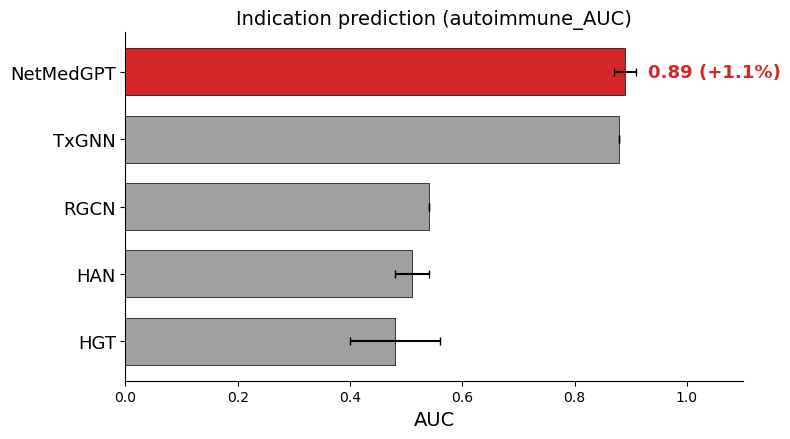

In [61]:
# plot AUC-indication: autoimmune
methods = ["RGCN", "HGT", "HAN","TxGNN", "NetMedGPT"]

means = []
stds = []
for i in methods:
    means.append(round(indication_aucs_autoimmune.loc[indication_aucs_autoimmune['method'] == i, 'mean'].item(), 2))
    stds.append(round(indication_aucs_autoimmune.loc[indication_aucs_autoimmune['method'] == i, 'std'].item(), 2))

# Sort by performance
data = sorted(zip(means, stds, methods), reverse=True)
means, stds, methods = zip(*data)

# Compute % improvement over best baseline (excluding BioMedFormer)
baseline_max = max(means[1:])
improvement = round((means[0] - baseline_max) / baseline_max * 100, 1)

# Colors: BioMedFormer = red, others = grey
colors = ['#D62728' if method == "NetMedGPT" else '#A0A0A0' for method in methods]

# Plot
# Define a consistent per-bar vertical space
bar_height = 0.7
vertical_padding = 1.0  # For title/labels

# Dynamically scale figure height based on number of bars
fig_height = len(methods) * bar_height + vertical_padding

fig, ax = plt.subplots(figsize=(8, fig_height))


y_pos = np.arange(len(methods))

bars = ax.barh(y_pos, means, xerr=stds, color=colors,
               capsize=3, edgecolor='black', linewidth=0.5, height=0.7)

# Reference line for best baseline
# ax.axvline(x=baseline_max, color='gray', linestyle='--', linewidth=1)
# ax.text(baseline_max + 0.01, -0.7, f"Best baseline ({baseline_max:.2f})", fontsize=12, color='gray')

# Annotate BioMedFormer
for i, (bar, method, val) in enumerate(zip(bars, methods, means)):
    if method == "NetMedGPT":
        ax.text(val + 0.04, bar.get_y() + bar.get_height() / 2,
                f"{val:.2f} (+{improvement}%)", va='center', fontsize=13, fontweight='bold', color='#D62728')

# Formatting
ax.set_yticks(y_pos)
ax.set_yticklabels(methods, fontsize=13)
ax.invert_yaxis()
ax.set_xlim(0, 1.1)
ax.set_xlabel("AUC", fontsize=14)
ax.set_title("Indication prediction (autoimmune_AUC)", fontsize=14)

# Clean borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)

# Save
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, "netmedgpt_indication_autoimmune_AUC.png"), dpi=300, bbox_inches="tight")
plt.show()

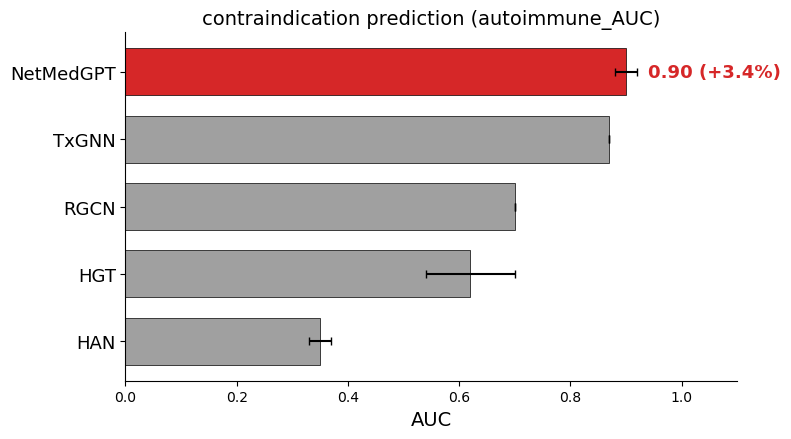

In [95]:
# plot AUC-contraindication: autoimmune
methods = ["RGCN", "HGT", "HAN","TxGNN", "NetMedGPT"]

means = []
stds = []
for i in methods:
    means.append(round(contraindication_aucs_autoimmune.loc[contraindication_aucs_autoimmune['method'] == i, 'mean'].item(), 2))
    stds.append(round(contraindication_aucs_autoimmune.loc[contraindication_aucs_autoimmune['method'] == i, 'std'].item(), 2))

# Sort by performance
data = sorted(zip(means, stds, methods), reverse=True)
means, stds, methods = zip(*data)

# Compute % improvement over best baseline (excluding BioMedFormer)
baseline_max = max(means[1:])
improvement = round((means[0] - baseline_max) / baseline_max * 100, 1)

# Colors: BioMedFormer = red, others = grey
colors = ['#D62728' if method == "NetMedGPT" else '#A0A0A0' for method in methods]

# Plot
# Define a consistent per-bar vertical space
bar_height = 0.7
vertical_padding = 1.0  # For title/labels

# Dynamically scale figure height based on number of bars
fig_height = len(methods) * bar_height + vertical_padding

fig, ax = plt.subplots(figsize=(8, fig_height))


y_pos = np.arange(len(methods))

bars = ax.barh(y_pos, means, xerr=stds, color=colors,
               capsize=3, edgecolor='black', linewidth=0.5, height=0.7)

# Reference line for best baseline
# ax.axvline(x=baseline_max, color='gray', linestyle='--', linewidth=1)
# ax.text(baseline_max + 0.01, -0.7, f"Best baseline ({baseline_max:.2f})", fontsize=12, color='gray')

# Annotate BioMedFormer
for i, (bar, method, val) in enumerate(zip(bars, methods, means)):
    if method == "NetMedGPT":
        ax.text(val + 0.04, bar.get_y() + bar.get_height() / 2,
                f"{val:.2f} (+{improvement}%)", va='center', fontsize=13, fontweight='bold', color='#D62728')

# Formatting
ax.set_yticks(y_pos)
ax.set_yticklabels(methods, fontsize=13)
ax.invert_yaxis()
ax.set_xlim(0, 1.1)
ax.set_xlabel("AUC", fontsize=14)
ax.set_title("contraindication prediction (autoimmune_AUC)", fontsize=14)

# Clean borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)

# Save
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, "netmedgpt_contraindication_autoimmune_AUC.png"), dpi=300, bbox_inches="tight")
plt.show()

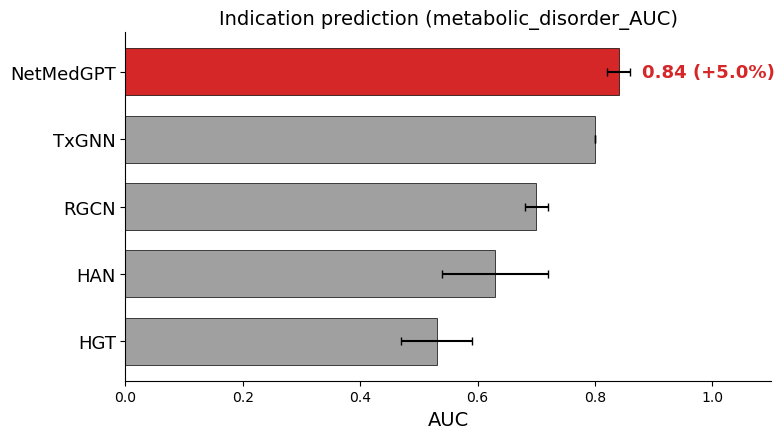

In [62]:
# plot AUC-indication: metabolic_disorder
methods = ["RGCN", "HGT", "HAN","TxGNN", "NetMedGPT"]

means = []
stds = []
for i in methods:
    means.append(round(indication_aucs_metabolic_disorder.loc[indication_aucs_metabolic_disorder['method'] == i, 'mean'].item(), 2))
    stds.append(round(indication_aucs_metabolic_disorder.loc[indication_aucs_metabolic_disorder['method'] == i, 'std'].item(), 2))


# Sort by performance
data = sorted(zip(means, stds, methods), reverse=True)
means, stds, methods = zip(*data)

# Compute % improvement over best baseline (excluding BioMedFormer)
baseline_max = max(means[1:])
improvement = round((means[0] - baseline_max) / baseline_max * 100, 1)

# Colors: BioMedFormer = red, others = grey
colors = ['#D62728' if method == "NetMedGPT" else '#A0A0A0' for method in methods]

# Plot
# Define a consistent per-bar vertical space
bar_height = 0.7
vertical_padding = 1.0  # For title/labels

# Dynamically scale figure height based on number of bars
fig_height = len(methods) * bar_height + vertical_padding

fig, ax = plt.subplots(figsize=(8, fig_height))


y_pos = np.arange(len(methods))

bars = ax.barh(y_pos, means, xerr=stds, color=colors,
               capsize=3, edgecolor='black', linewidth=0.5, height=0.7)

# Reference line for best baseline
# ax.axvline(x=baseline_max, color='gray', linestyle='--', linewidth=1)
# ax.text(baseline_max + 0.01, -0.7, f"Best baseline ({baseline_max:.2f})", fontsize=12, color='gray')

# Annotate BioMedFormer
for i, (bar, method, val) in enumerate(zip(bars, methods, means)):
    if method == "NetMedGPT":
        ax.text(val + 0.04, bar.get_y() + bar.get_height() / 2,
                f"{val:.2f} (+{improvement}%)", va='center', fontsize=13, fontweight='bold', color='#D62728')

# Formatting
ax.set_yticks(y_pos)
ax.set_yticklabels(methods, fontsize=13)
ax.invert_yaxis()
ax.set_xlim(0, 1.1)
ax.set_xlabel("AUC", fontsize=14)
ax.set_title("Indication prediction (metabolic_disorder_AUC)", fontsize=14)

# Clean borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)

# Save
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, "netmedgpt_indication_metabolic_disorder_AUC.png"), dpi=300, bbox_inches="tight")
plt.show()

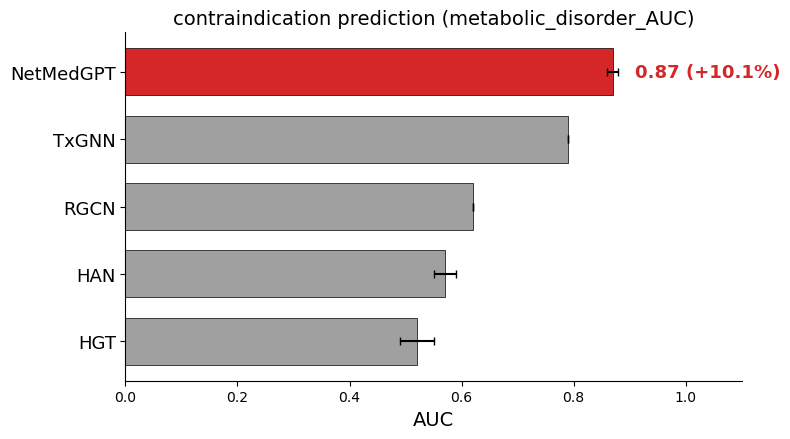

In [96]:
# plot AUC-contraindication: metabolic_disorder
methods = ["RGCN", "HGT", "HAN","TxGNN", "NetMedGPT"]

means = []
stds = []
for i in methods:
    means.append(round(contraindication_aucs_metabolic_disorder.loc[contraindication_aucs_metabolic_disorder['method'] == i, 'mean'].item(), 2))
    stds.append(round(contraindication_aucs_metabolic_disorder.loc[contraindication_aucs_metabolic_disorder['method'] == i, 'std'].item(), 2))


# Sort by performance
data = sorted(zip(means, stds, methods), reverse=True)
means, stds, methods = zip(*data)

# Compute % improvement over best baseline (excluding BioMedFormer)
baseline_max = max(means[1:])
improvement = round((means[0] - baseline_max) / baseline_max * 100, 1)

# Colors: BioMedFormer = red, others = grey
colors = ['#D62728' if method == "NetMedGPT" else '#A0A0A0' for method in methods]

# Plot
# Define a consistent per-bar vertical space
bar_height = 0.7
vertical_padding = 1.0  # For title/labels

# Dynamically scale figure height based on number of bars
fig_height = len(methods) * bar_height + vertical_padding

fig, ax = plt.subplots(figsize=(8, fig_height))


y_pos = np.arange(len(methods))

bars = ax.barh(y_pos, means, xerr=stds, color=colors,
               capsize=3, edgecolor='black', linewidth=0.5, height=0.7)

# Reference line for best baseline
# ax.axvline(x=baseline_max, color='gray', linestyle='--', linewidth=1)
# ax.text(baseline_max + 0.01, -0.7, f"Best baseline ({baseline_max:.2f})", fontsize=12, color='gray')

# Annotate BioMedFormer
for i, (bar, method, val) in enumerate(zip(bars, methods, means)):
    if method == "NetMedGPT":
        ax.text(val + 0.04, bar.get_y() + bar.get_height() / 2,
                f"{val:.2f} (+{improvement}%)", va='center', fontsize=13, fontweight='bold', color='#D62728')

# Formatting
ax.set_yticks(y_pos)
ax.set_yticklabels(methods, fontsize=13)
ax.invert_yaxis()
ax.set_xlim(0, 1.1)
ax.set_xlabel("AUC", fontsize=14)
ax.set_title("contraindication prediction (metabolic_disorder_AUC)", fontsize=14)

# Clean borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)

# Save
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, "netmedgpt_contraindication_metabolic_disorder_AUC.png"), dpi=300, bbox_inches="tight")
plt.show()

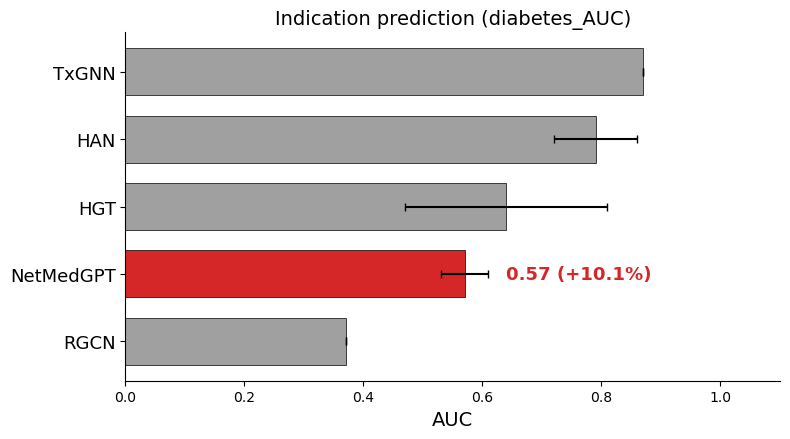

In [63]:
# plot AUC-indication: diabetes
methods = ["RGCN", "HGT", "HAN","TxGNN", "NetMedGPT"]

means = []
stds = []
for i in methods:
    means.append(round(indication_aucs_diabetes.loc[indication_aucs_diabetes['method'] == i, 'mean'].item(), 2))
    stds.append(round(indication_aucs_diabetes.loc[indication_aucs_diabetes['method'] == i, 'std'].item(), 2))


# Sort by performance
data = sorted(zip(means, stds, methods), reverse=True)
means, stds, methods = zip(*data)

# Compute % improvement over best baseline (excluding BioMedFormer)
baseline_max = max(means[1:])
improvement = round((means[0] - baseline_max) / baseline_max * 100, 1)

# Colors: BioMedFormer = red, others = grey
colors = ['#D62728' if method == "NetMedGPT" else '#A0A0A0' for method in methods]

# Plot
# Define a consistent per-bar vertical space
bar_height = 0.7
vertical_padding = 1.0  # For title/labels

# Dynamically scale figure height based on number of bars
fig_height = len(methods) * bar_height + vertical_padding

fig, ax = plt.subplots(figsize=(8, fig_height))


y_pos = np.arange(len(methods))

bars = ax.barh(y_pos, means, xerr=stds, color=colors,
               capsize=3, edgecolor='black', linewidth=0.5, height=0.7)

# Reference line for best baseline
# ax.axvline(x=baseline_max, color='gray', linestyle='--', linewidth=1)
# ax.text(baseline_max + 0.01, -0.7, f"Best baseline ({baseline_max:.2f})", fontsize=12, color='gray')

# Annotate BioMedFormer
for i, (bar, method, val) in enumerate(zip(bars, methods, means)):
    if method == "NetMedGPT":
        ax.text(val + 0.07, bar.get_y() + bar.get_height() / 2,
                f"{val:.2f} (+{improvement}%)", va='center', fontsize=13, fontweight='bold', color='#D62728')

# Formatting
ax.set_yticks(y_pos)
ax.set_yticklabels(methods, fontsize=13)
ax.invert_yaxis()
ax.set_xlim(0, 1.1)
ax.set_xlabel("AUC", fontsize=14)
ax.set_title("Indication prediction (diabetes_AUC)", fontsize=14)

# Clean borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)

# Save
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, "netmedgpt_indication_diabetes_AUC.png"), dpi=300, bbox_inches="tight")
plt.show()

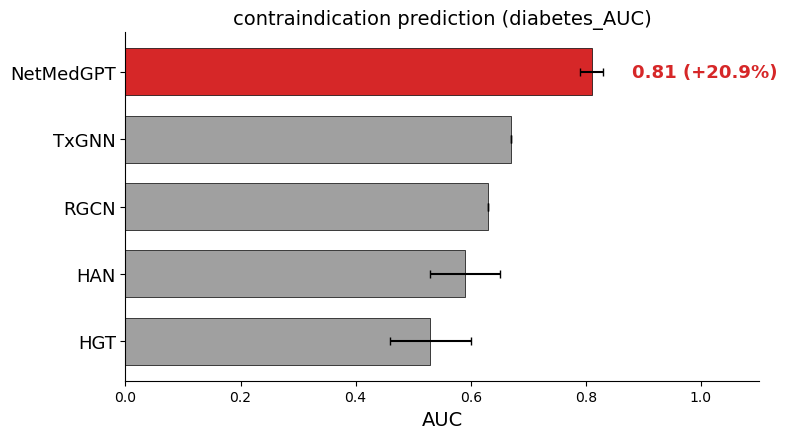

In [97]:
# plot AUC-contraindication: diabetes
methods = ["RGCN", "HGT", "HAN","TxGNN", "NetMedGPT"]

means = []
stds = []
for i in methods:
    means.append(round(contraindication_aucs_diabetes.loc[contraindication_aucs_diabetes['method'] == i, 'mean'].item(), 2))
    stds.append(round(contraindication_aucs_diabetes.loc[contraindication_aucs_diabetes['method'] == i, 'std'].item(), 2))


# Sort by performance
data = sorted(zip(means, stds, methods), reverse=True)
means, stds, methods = zip(*data)

# Compute % improvement over best baseline (excluding BioMedFormer)
baseline_max = max(means[1:])
improvement = round((means[0] - baseline_max) / baseline_max * 100, 1)

# Colors: BioMedFormer = red, others = grey
colors = ['#D62728' if method == "NetMedGPT" else '#A0A0A0' for method in methods]

# Plot
# Define a consistent per-bar vertical space
bar_height = 0.7
vertical_padding = 1.0  # For title/labels

# Dynamically scale figure height based on number of bars
fig_height = len(methods) * bar_height + vertical_padding

fig, ax = plt.subplots(figsize=(8, fig_height))


y_pos = np.arange(len(methods))

bars = ax.barh(y_pos, means, xerr=stds, color=colors,
               capsize=3, edgecolor='black', linewidth=0.5, height=0.7)

# Reference line for best baseline
# ax.axvline(x=baseline_max, color='gray', linestyle='--', linewidth=1)
# ax.text(baseline_max + 0.01, -0.7, f"Best baseline ({baseline_max:.2f})", fontsize=12, color='gray')

# Annotate BioMedFormer
for i, (bar, method, val) in enumerate(zip(bars, methods, means)):
    if method == "NetMedGPT":
        ax.text(val + 0.07, bar.get_y() + bar.get_height() / 2,
                f"{val:.2f} (+{improvement}%)", va='center', fontsize=13, fontweight='bold', color='#D62728')

# Formatting
ax.set_yticks(y_pos)
ax.set_yticklabels(methods, fontsize=13)
ax.invert_yaxis()
ax.set_xlim(0, 1.1)
ax.set_xlabel("AUC", fontsize=14)
ax.set_title("contraindication prediction (diabetes_AUC)", fontsize=14)

# Clean borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)

# Save
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, "netmedgpt_contraindication_diabetes_AUC.png"), dpi=300, bbox_inches="tight")
plt.show()

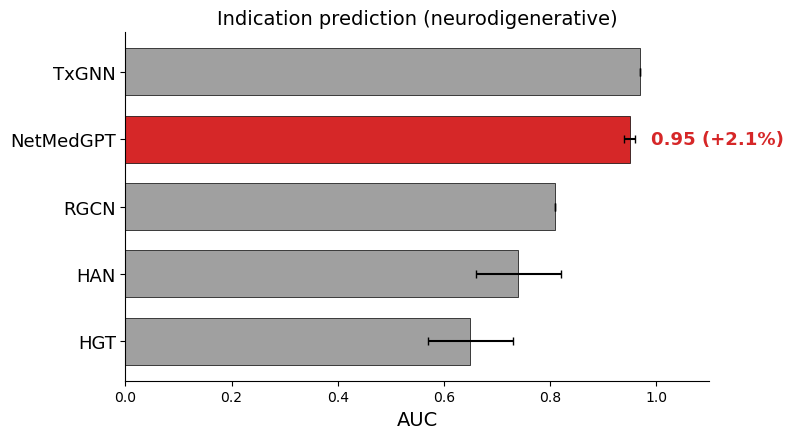

In [65]:
# plot AUC-indication: neurodigenerative
methods = ["RGCN", "HGT", "HAN","TxGNN", "NetMedGPT"]

means = []
stds = []
for i in methods:
    means.append(round(indication_aucs_neurodigenerative.loc[indication_aucs_neurodigenerative['method'] == i, 'mean'].item(), 2))
    stds.append(round(indication_aucs_neurodigenerative.loc[indication_aucs_neurodigenerative['method'] == i, 'std'].item(), 2))

# Sort by performance
data = sorted(zip(means, stds, methods), reverse=True)
means, stds, methods = zip(*data)

# Compute % improvement over best baseline (excluding BioMedFormer)
baseline_max = max(means[1:])
improvement = round((means[0] - baseline_max) / baseline_max * 100, 1)

# Colors: BioMedFormer = red, others = grey
colors = ['#D62728' if method == "NetMedGPT" else '#A0A0A0' for method in methods]

# Plot
# Define a consistent per-bar vertical space
bar_height = 0.7
vertical_padding = 1.0  # For title/labels

# Dynamically scale figure height based on number of bars
fig_height = len(methods) * bar_height + vertical_padding

fig, ax = plt.subplots(figsize=(8, fig_height))


y_pos = np.arange(len(methods))

bars = ax.barh(y_pos, means, xerr=stds, color=colors,
               capsize=3, edgecolor='black', linewidth=0.5, height=0.7)

# Reference line for best baseline
# ax.axvline(x=baseline_max, color='gray', linestyle='--', linewidth=1)
# ax.text(baseline_max + 0.01, -0.7, f"Best baseline ({baseline_max:.2f})", fontsize=12, color='gray')

# Annotate BioMedFormer
for i, (bar, method, val) in enumerate(zip(bars, methods, means)):
    if method == "NetMedGPT":
        ax.text(val + 0.04, bar.get_y() + bar.get_height() / 2,
                f"{val:.2f} (+{improvement}%)", va='center', fontsize=13, fontweight='bold', color='#D62728')

# Formatting
ax.set_yticks(y_pos)
ax.set_yticklabels(methods, fontsize=13)
ax.invert_yaxis()
ax.set_xlim(0, 1.1)
ax.set_xlabel("AUC", fontsize=14)
ax.set_title("Indication prediction (neurodigenerative)", fontsize=14)

# Clean borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)

# Save
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, "netmedgpt_indication_neurodigenerative_AUC.png"), dpi=300, bbox_inches="tight")
plt.show()

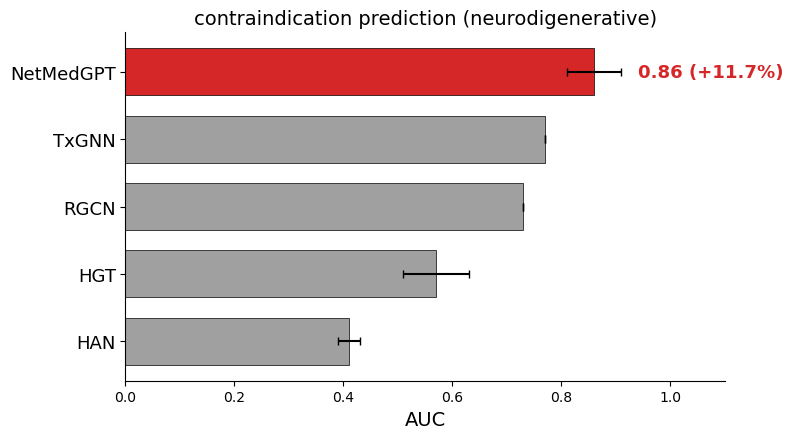

In [99]:
# plot AUC-contraindication: neurodigenerative
methods = ["RGCN", "HGT", "HAN","TxGNN", "NetMedGPT"]

means = []
stds = []
for i in methods:
    means.append(round(contraindication_aucs_neurodigenerative.loc[contraindication_aucs_neurodigenerative['method'] == i, 'mean'].item(), 2))
    stds.append(round(contraindication_aucs_neurodigenerative.loc[contraindication_aucs_neurodigenerative['method'] == i, 'std'].item(), 2))

# Sort by performance
data = sorted(zip(means, stds, methods), reverse=True)
means, stds, methods = zip(*data)

# Compute % improvement over best baseline (excluding BioMedFormer)
baseline_max = max(means[1:])
improvement = round((means[0] - baseline_max) / baseline_max * 100, 1)

# Colors: BioMedFormer = red, others = grey
colors = ['#D62728' if method == "NetMedGPT" else '#A0A0A0' for method in methods]

# Plot
# Define a consistent per-bar vertical space
bar_height = 0.7
vertical_padding = 1.0  # For title/labels

# Dynamically scale figure height based on number of bars
fig_height = len(methods) * bar_height + vertical_padding

fig, ax = plt.subplots(figsize=(8, fig_height))


y_pos = np.arange(len(methods))

bars = ax.barh(y_pos, means, xerr=stds, color=colors,
               capsize=3, edgecolor='black', linewidth=0.5, height=0.7)

# Reference line for best baseline
# ax.axvline(x=baseline_max, color='gray', linestyle='--', linewidth=1)
# ax.text(baseline_max + 0.01, -0.7, f"Best baseline ({baseline_max:.2f})", fontsize=12, color='gray')

# Annotate BioMedFormer
for i, (bar, method, val) in enumerate(zip(bars, methods, means)):
    if method == "NetMedGPT":
        ax.text(val + 0.08, bar.get_y() + bar.get_height() / 2,
                f"{val:.2f} (+{improvement}%)", va='center', fontsize=13, fontweight='bold', color='#D62728')

# Formatting
ax.set_yticks(y_pos)
ax.set_yticklabels(methods, fontsize=13)
ax.invert_yaxis()
ax.set_xlim(0, 1.1)
ax.set_xlabel("AUC", fontsize=14)
ax.set_title("contraindication prediction (neurodigenerative)", fontsize=14)

# Clean borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)

# Save
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, "netmedgpt_contraindication_neurodigenerative_AUC.png"), dpi=300, bbox_inches="tight")
plt.show()

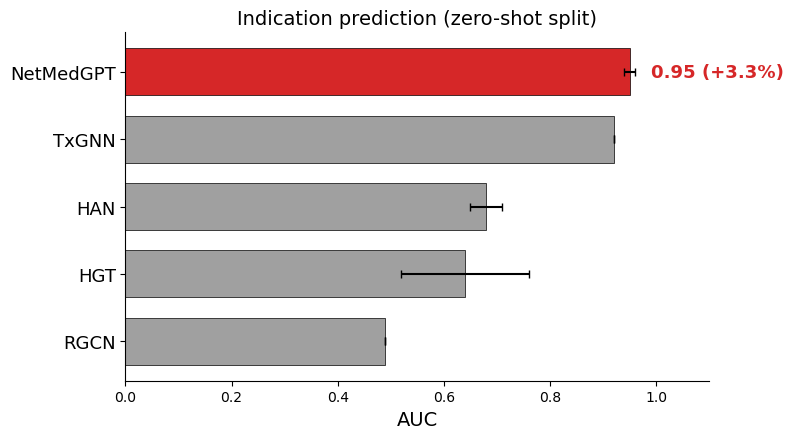

In [66]:
# plot AUC-indication: cell_proliferation
methods = ["RGCN", "HGT", "HAN","TxGNN", "NetMedGPT"]

means = []
stds = []
for i in methods:
    means.append(round(indication_aucs_cell_proliferation.loc[indication_aucs_cell_proliferation['method'] == i, 'mean'].item(), 2))
    stds.append(round(indication_aucs_cell_proliferation.loc[indication_aucs_cell_proliferation['method'] == i, 'std'].item(), 2))


# Sort by performance
data = sorted(zip(means, stds, methods), reverse=True)
means, stds, methods = zip(*data)

# Compute % improvement over best baseline (excluding BioMedFormer)
baseline_max = max(means[1:])
improvement = round((means[0] - baseline_max) / baseline_max * 100, 1)

# Colors: BioMedFormer = red, others = grey
colors = ['#D62728' if method == "NetMedGPT" else '#A0A0A0' for method in methods]

# Plot
# Define a consistent per-bar vertical space
bar_height = 0.7
vertical_padding = 1.0  # For title/labels

# Dynamically scale figure height based on number of bars
fig_height = len(methods) * bar_height + vertical_padding

fig, ax = plt.subplots(figsize=(8, fig_height))


y_pos = np.arange(len(methods))

bars = ax.barh(y_pos, means, xerr=stds, color=colors,
               capsize=3, edgecolor='black', linewidth=0.5, height=0.7)

# Reference line for best baseline
# ax.axvline(x=baseline_max, color='gray', linestyle='--', linewidth=1)
# ax.text(baseline_max + 0.01, -0.7, f"Best baseline ({baseline_max:.2f})", fontsize=12, color='gray')

# Annotate BioMedFormer
for i, (bar, method, val) in enumerate(zip(bars, methods, means)):
    if method == "NetMedGPT":
        ax.text(val + 0.04, bar.get_y() + bar.get_height() / 2,
                f"{val:.2f} (+{improvement}%)", va='center', fontsize=13, fontweight='bold', color='#D62728')

# Formatting
ax.set_yticks(y_pos)
ax.set_yticklabels(methods, fontsize=13)
ax.invert_yaxis()
ax.set_xlim(0, 1.1)
ax.set_xlabel("AUC", fontsize=14)
ax.set_title("Indication prediction (zero-shot split)", fontsize=14)

# Clean borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)

# Save
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, "netmedgpt_indication_cell_proliferation_AUC.png"), dpi=300, bbox_inches="tight")
plt.show()

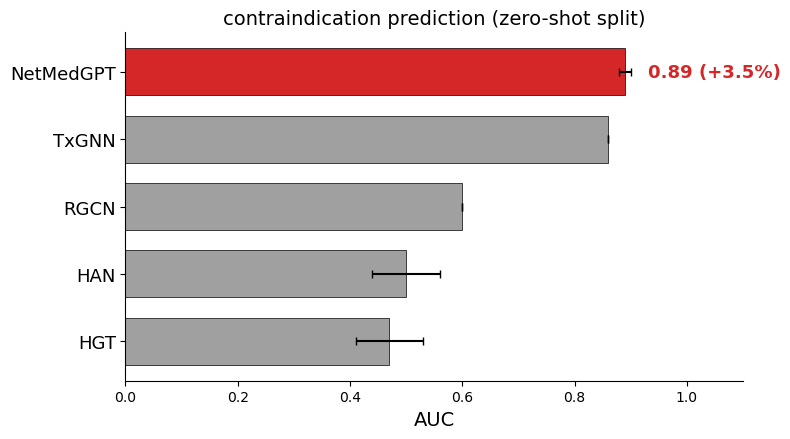

In [100]:
# plot AUC-contraindication: cell_proliferation
methods = ["RGCN", "HGT", "HAN","TxGNN", "NetMedGPT"]

means = []
stds = []
for i in methods:
    means.append(round(contraindication_aucs_cell_proliferation.loc[contraindication_aucs_cell_proliferation['method'] == i, 'mean'].item(), 2))
    stds.append(round(contraindication_aucs_cell_proliferation.loc[contraindication_aucs_cell_proliferation['method'] == i, 'std'].item(), 2))


# Sort by performance
data = sorted(zip(means, stds, methods), reverse=True)
means, stds, methods = zip(*data)

# Compute % improvement over best baseline (excluding BioMedFormer)
baseline_max = max(means[1:])
improvement = round((means[0] - baseline_max) / baseline_max * 100, 1)

# Colors: BioMedFormer = red, others = grey
colors = ['#D62728' if method == "NetMedGPT" else '#A0A0A0' for method in methods]

# Plot
# Define a consistent per-bar vertical space
bar_height = 0.7
vertical_padding = 1.0  # For title/labels

# Dynamically scale figure height based on number of bars
fig_height = len(methods) * bar_height + vertical_padding

fig, ax = plt.subplots(figsize=(8, fig_height))


y_pos = np.arange(len(methods))

bars = ax.barh(y_pos, means, xerr=stds, color=colors,
               capsize=3, edgecolor='black', linewidth=0.5, height=0.7)

# Reference line for best baseline
# ax.axvline(x=baseline_max, color='gray', linestyle='--', linewidth=1)
# ax.text(baseline_max + 0.01, -0.7, f"Best baseline ({baseline_max:.2f})", fontsize=12, color='gray')

# Annotate BioMedFormer
for i, (bar, method, val) in enumerate(zip(bars, methods, means)):
    if method == "NetMedGPT":
        ax.text(val + 0.04, bar.get_y() + bar.get_height() / 2,
                f"{val:.2f} (+{improvement}%)", va='center', fontsize=13, fontweight='bold', color='#D62728')

# Formatting
ax.set_yticks(y_pos)
ax.set_yticklabels(methods, fontsize=13)
ax.invert_yaxis()
ax.set_xlim(0, 1.1)
ax.set_xlabel("AUC", fontsize=14)
ax.set_title("contraindication prediction (zero-shot split)", fontsize=14)

# Clean borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)

# Save
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, "netmedgpt_contraindication_cell_proliferation_AUC.png"), dpi=300, bbox_inches="tight")
plt.show()

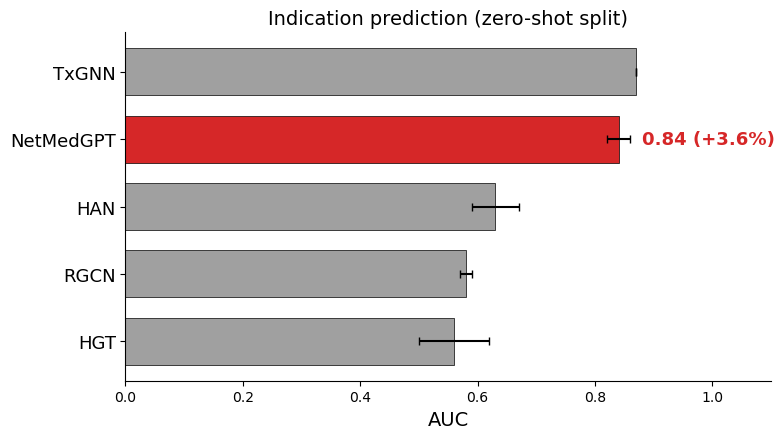

In [67]:
# plot AUC-indication: mental_health
methods = ["RGCN", "HGT", "HAN","TxGNN", "NetMedGPT"]

means = []
stds = []
for i in methods:
    means.append(round(indication_aucs_mental_health.loc[indication_aucs_mental_health['method'] == i, 'mean'].item(), 2))
    stds.append(round(indication_aucs_mental_health.loc[indication_aucs_mental_health['method'] == i, 'std'].item(), 2))


# Sort by performance
data = sorted(zip(means, stds, methods), reverse=True)
means, stds, methods = zip(*data)

# Compute % improvement over best baseline (excluding BioMedFormer)
baseline_max = max(means[1:])
improvement = round((means[0] - baseline_max) / baseline_max * 100, 1)

# Colors: BioMedFormer = red, others = grey
colors = ['#D62728' if method == "NetMedGPT" else '#A0A0A0' for method in methods]

# Plot
# Define a consistent per-bar vertical space
bar_height = 0.7
vertical_padding = 1.0  # For title/labels

# Dynamically scale figure height based on number of bars
fig_height = len(methods) * bar_height + vertical_padding

fig, ax = plt.subplots(figsize=(8, fig_height))


y_pos = np.arange(len(methods))

bars = ax.barh(y_pos, means, xerr=stds, color=colors,
               capsize=3, edgecolor='black', linewidth=0.5, height=0.7)

# Reference line for best baseline
# ax.axvline(x=baseline_max, color='gray', linestyle='--', linewidth=1)
# ax.text(baseline_max + 0.01, -0.7, f"Best baseline ({baseline_max:.2f})", fontsize=12, color='gray')

# Annotate BioMedFormer
for i, (bar, method, val) in enumerate(zip(bars, methods, means)):
    if method == "NetMedGPT":
        ax.text(val + 0.04, bar.get_y() + bar.get_height() / 2,
                f"{val:.2f} (+{improvement}%)", va='center', fontsize=13, fontweight='bold', color='#D62728')

# Formatting
ax.set_yticks(y_pos)
ax.set_yticklabels(methods, fontsize=13)
ax.invert_yaxis()
ax.set_xlim(0, 1.1)
ax.set_xlabel("AUC", fontsize=14)
ax.set_title("Indication prediction (zero-shot split)", fontsize=14)

# Clean borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)

# Save
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, "netmedgpt_indication_mental_health_AUC.png"), dpi=300, bbox_inches="tight")
plt.show()

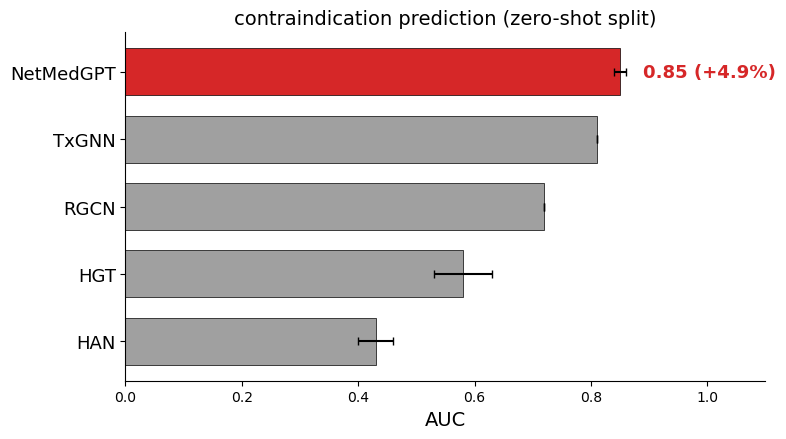

In [101]:
# plot AUC-contraindication: mental_health
methods = ["RGCN", "HGT", "HAN","TxGNN", "NetMedGPT"]

means = []
stds = []
for i in methods:
    means.append(round(contraindication_aucs_mental_health.loc[contraindication_aucs_mental_health['method'] == i, 'mean'].item(), 2))
    stds.append(round(contraindication_aucs_mental_health.loc[contraindication_aucs_mental_health['method'] == i, 'std'].item(), 2))


# Sort by performance
data = sorted(zip(means, stds, methods), reverse=True)
means, stds, methods = zip(*data)

# Compute % improvement over best baseline (excluding BioMedFormer)
baseline_max = max(means[1:])
improvement = round((means[0] - baseline_max) / baseline_max * 100, 1)

# Colors: BioMedFormer = red, others = grey
colors = ['#D62728' if method == "NetMedGPT" else '#A0A0A0' for method in methods]

# Plot
# Define a consistent per-bar vertical space
bar_height = 0.7
vertical_padding = 1.0  # For title/labels

# Dynamically scale figure height based on number of bars
fig_height = len(methods) * bar_height + vertical_padding

fig, ax = plt.subplots(figsize=(8, fig_height))


y_pos = np.arange(len(methods))

bars = ax.barh(y_pos, means, xerr=stds, color=colors,
               capsize=3, edgecolor='black', linewidth=0.5, height=0.7)

# Reference line for best baseline
# ax.axvline(x=baseline_max, color='gray', linestyle='--', linewidth=1)
# ax.text(baseline_max + 0.01, -0.7, f"Best baseline ({baseline_max:.2f})", fontsize=12, color='gray')

# Annotate BioMedFormer
for i, (bar, method, val) in enumerate(zip(bars, methods, means)):
    if method == "NetMedGPT":
        ax.text(val + 0.04, bar.get_y() + bar.get_height() / 2,
                f"{val:.2f} (+{improvement}%)", va='center', fontsize=13, fontweight='bold', color='#D62728')

# Formatting
ax.set_yticks(y_pos)
ax.set_yticklabels(methods, fontsize=13)
ax.invert_yaxis()
ax.set_xlim(0, 1.1)
ax.set_xlabel("AUC", fontsize=14)
ax.set_title("contraindication prediction (zero-shot split)", fontsize=14)

# Clean borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)

# Save
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, "netmedgpt_contraindication_mental_health_AUC.png"), dpi=300, bbox_inches="tight")
plt.show()

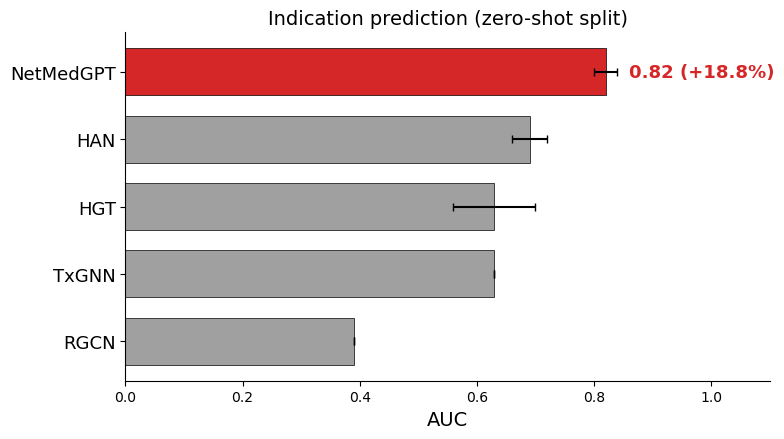

In [68]:
# plot AUC-indication: cardiovascular
methods = ["RGCN", "HGT", "HAN","TxGNN", "NetMedGPT"]

means = []
stds = []
for i in methods:
    means.append(round(indication_aucs_cardiovascular.loc[indication_aucs_cardiovascular['method'] == i, 'mean'].item(), 2))
    stds.append(round(indication_aucs_cardiovascular.loc[indication_aucs_cardiovascular['method'] == i, 'std'].item(), 2))


# Sort by performance
data = sorted(zip(means, stds, methods), reverse=True)
means, stds, methods = zip(*data)

# Compute % improvement over best baseline (excluding BioMedFormer)
baseline_max = max(means[1:])
improvement = round((means[0] - baseline_max) / baseline_max * 100, 1)

# Colors: BioMedFormer = red, others = grey
colors = ['#D62728' if method == "NetMedGPT" else '#A0A0A0' for method in methods]

# Plot
# Define a consistent per-bar vertical space
bar_height = 0.7
vertical_padding = 1.0  # For title/labels

# Dynamically scale figure height based on number of bars
fig_height = len(methods) * bar_height + vertical_padding

fig, ax = plt.subplots(figsize=(8, fig_height))


y_pos = np.arange(len(methods))

bars = ax.barh(y_pos, means, xerr=stds, color=colors,
               capsize=3, edgecolor='black', linewidth=0.5, height=0.7)

# Reference line for best baseline
# ax.axvline(x=baseline_max, color='gray', linestyle='--', linewidth=1)
# ax.text(baseline_max + 0.01, -0.7, f"Best baseline ({baseline_max:.2f})", fontsize=12, color='gray')

# Annotate BioMedFormer
for i, (bar, method, val) in enumerate(zip(bars, methods, means)):
    if method == "NetMedGPT":
        ax.text(val + 0.04, bar.get_y() + bar.get_height() / 2,
                f"{val:.2f} (+{improvement}%)", va='center', fontsize=13, fontweight='bold', color='#D62728')

# Formatting
ax.set_yticks(y_pos)
ax.set_yticklabels(methods, fontsize=13)
ax.invert_yaxis()
ax.set_xlim(0, 1.1)
ax.set_xlabel("AUC", fontsize=14)
ax.set_title("Indication prediction (zero-shot split)", fontsize=14)

# Clean borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)

# Save
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, "netmedgpt_indication_cardiovascular_AUC.png"), dpi=300, bbox_inches="tight")
plt.show()

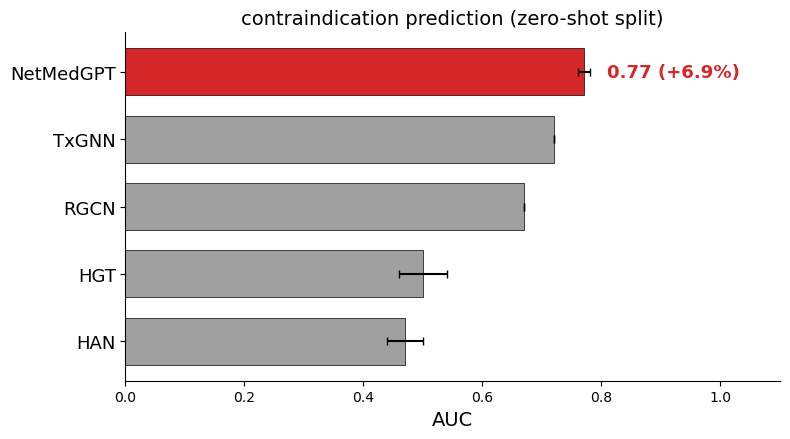

In [102]:
# plot AUC-contraindication: cardiovascular
methods = ["RGCN", "HGT", "HAN","TxGNN", "NetMedGPT"]

means = []
stds = []
for i in methods:
    means.append(round(contraindication_aucs_cardiovascular.loc[contraindication_aucs_cardiovascular['method'] == i, 'mean'].item(), 2))
    stds.append(round(contraindication_aucs_cardiovascular.loc[contraindication_aucs_cardiovascular['method'] == i, 'std'].item(), 2))


# Sort by performance
data = sorted(zip(means, stds, methods), reverse=True)
means, stds, methods = zip(*data)

# Compute % improvement over best baseline (excluding BioMedFormer)
baseline_max = max(means[1:])
improvement = round((means[0] - baseline_max) / baseline_max * 100, 1)

# Colors: BioMedFormer = red, others = grey
colors = ['#D62728' if method == "NetMedGPT" else '#A0A0A0' for method in methods]

# Plot
# Define a consistent per-bar vertical space
bar_height = 0.7
vertical_padding = 1.0  # For title/labels

# Dynamically scale figure height based on number of bars
fig_height = len(methods) * bar_height + vertical_padding

fig, ax = plt.subplots(figsize=(8, fig_height))


y_pos = np.arange(len(methods))

bars = ax.barh(y_pos, means, xerr=stds, color=colors,
               capsize=3, edgecolor='black', linewidth=0.5, height=0.7)

# Reference line for best baseline
# ax.axvline(x=baseline_max, color='gray', linestyle='--', linewidth=1)
# ax.text(baseline_max + 0.01, -0.7, f"Best baseline ({baseline_max:.2f})", fontsize=12, color='gray')

# Annotate BioMedFormer
for i, (bar, method, val) in enumerate(zip(bars, methods, means)):
    if method == "NetMedGPT":
        ax.text(val + 0.04, bar.get_y() + bar.get_height() / 2,
                f"{val:.2f} (+{improvement}%)", va='center', fontsize=13, fontweight='bold', color='#D62728')

# Formatting
ax.set_yticks(y_pos)
ax.set_yticklabels(methods, fontsize=13)
ax.invert_yaxis()
ax.set_xlim(0, 1.1)
ax.set_xlabel("AUC", fontsize=14)
ax.set_title("contraindication prediction (zero-shot split)", fontsize=14)

# Clean borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)

# Save
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, "netmedgpt_contraindication_cardiovascular_AUC.png"), dpi=300, bbox_inches="tight")
plt.show()

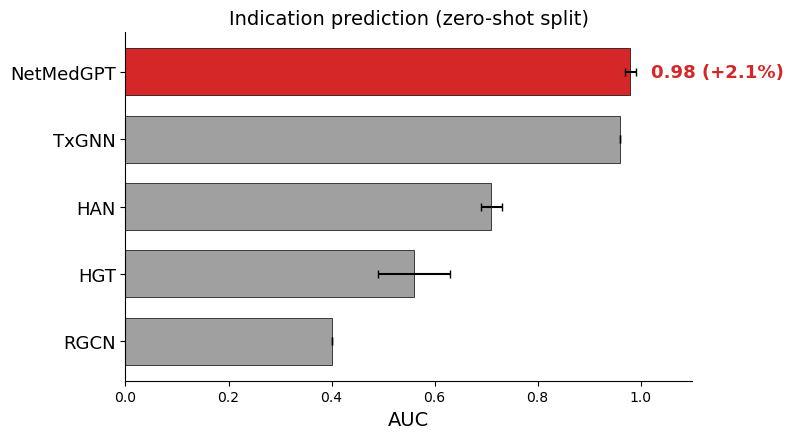

In [82]:
# plot AUC-indication: anemia
methods = ["RGCN", "HGT", "HAN","TxGNN", "NetMedGPT"]

means = []
stds = []
for i in methods:
    means.append(round(indication_aucs_anemia.loc[indication_aucs_anemia['method'] == i, 'mean'].item(), 2))
    stds.append(round(indication_aucs_anemia.loc[indication_aucs_anemia['method'] == i, 'std'].item(), 2))


# Sort by performance
data = sorted(zip(means, stds, methods), reverse=True)
means, stds, methods = zip(*data)

# Compute % improvement over best baseline (excluding BioMedFormer)
baseline_max = max(means[1:])
improvement = round((means[0] - baseline_max) / baseline_max * 100, 1)

# Colors: BioMedFormer = red, others = grey
colors = ['#D62728' if method == "NetMedGPT" else '#A0A0A0' for method in methods]

# Plot
# Define a consistent per-bar vertical space
bar_height = 0.7
vertical_padding = 1.0  # For title/labels

# Dynamically scale figure height based on number of bars
fig_height = len(methods) * bar_height + vertical_padding

fig, ax = plt.subplots(figsize=(8, fig_height))


y_pos = np.arange(len(methods))

bars = ax.barh(y_pos, means, xerr=stds, color=colors,
               capsize=3, edgecolor='black', linewidth=0.5, height=0.7)

# Reference line for best baseline
# ax.axvline(x=baseline_max, color='gray', linestyle='--', linewidth=1)
# ax.text(baseline_max + 0.01, -0.7, f"Best baseline ({baseline_max:.2f})", fontsize=12, color='gray')

# Annotate BioMedFormer
for i, (bar, method, val) in enumerate(zip(bars, methods, means)):
    if method == "NetMedGPT":
        ax.text(val + 0.04, bar.get_y() + bar.get_height() / 2,
                f"{val:.2f} (+{improvement}%)", va='center', fontsize=13, fontweight='bold', color='#D62728')

# Formatting
ax.set_yticks(y_pos)
ax.set_yticklabels(methods, fontsize=13)
ax.invert_yaxis()
ax.set_xlim(0, 1.1)
ax.set_xlabel("AUC", fontsize=14)
ax.set_title("Indication prediction (zero-shot split)", fontsize=14)

# Clean borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)

# Save
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, "netmedgpt_indication_anemia_AUC.png"), dpi=300, bbox_inches="tight")
plt.show()

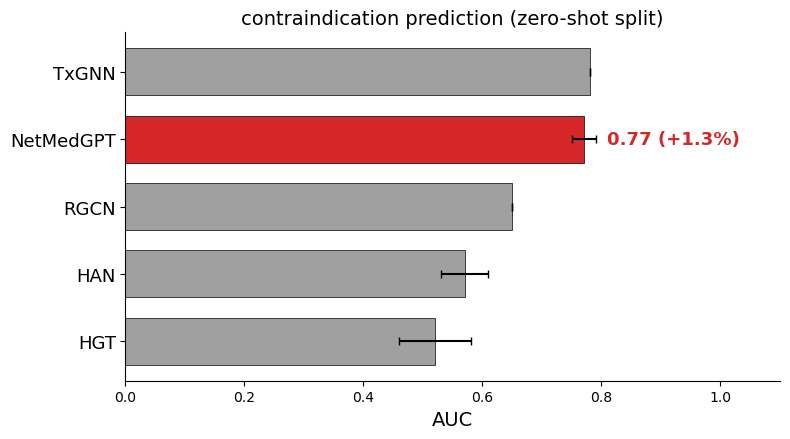

In [103]:
# plot AUC-contraindication: anemia
methods = ["RGCN", "HGT", "HAN","TxGNN", "NetMedGPT"]

means = []
stds = []
for i in methods:
    means.append(round(contraindication_aucs_anemia.loc[contraindication_aucs_anemia['method'] == i, 'mean'].item(), 2))
    stds.append(round(contraindication_aucs_anemia.loc[contraindication_aucs_anemia['method'] == i, 'std'].item(), 2))


# Sort by performance
data = sorted(zip(means, stds, methods), reverse=True)
means, stds, methods = zip(*data)

# Compute % improvement over best baseline (excluding BioMedFormer)
baseline_max = max(means[1:])
improvement = round((means[0] - baseline_max) / baseline_max * 100, 1)

# Colors: BioMedFormer = red, others = grey
colors = ['#D62728' if method == "NetMedGPT" else '#A0A0A0' for method in methods]

# Plot
# Define a consistent per-bar vertical space
bar_height = 0.7
vertical_padding = 1.0  # For title/labels

# Dynamically scale figure height based on number of bars
fig_height = len(methods) * bar_height + vertical_padding

fig, ax = plt.subplots(figsize=(8, fig_height))


y_pos = np.arange(len(methods))

bars = ax.barh(y_pos, means, xerr=stds, color=colors,
               capsize=3, edgecolor='black', linewidth=0.5, height=0.7)

# Reference line for best baseline
# ax.axvline(x=baseline_max, color='gray', linestyle='--', linewidth=1)
# ax.text(baseline_max + 0.01, -0.7, f"Best baseline ({baseline_max:.2f})", fontsize=12, color='gray')

# Annotate BioMedFormer
for i, (bar, method, val) in enumerate(zip(bars, methods, means)):
    if method == "NetMedGPT":
        ax.text(val + 0.04, bar.get_y() + bar.get_height() / 2,
                f"{val:.2f} (+{improvement}%)", va='center', fontsize=13, fontweight='bold', color='#D62728')

# Formatting
ax.set_yticks(y_pos)
ax.set_yticklabels(methods, fontsize=13)
ax.invert_yaxis()
ax.set_xlim(0, 1.1)
ax.set_xlabel("AUC", fontsize=14)
ax.set_title("contraindication prediction (zero-shot split)", fontsize=14)

# Clean borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)

# Save
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, "netmedgpt_contraindication_anemia_AUC.png"), dpi=300, bbox_inches="tight")
plt.show()

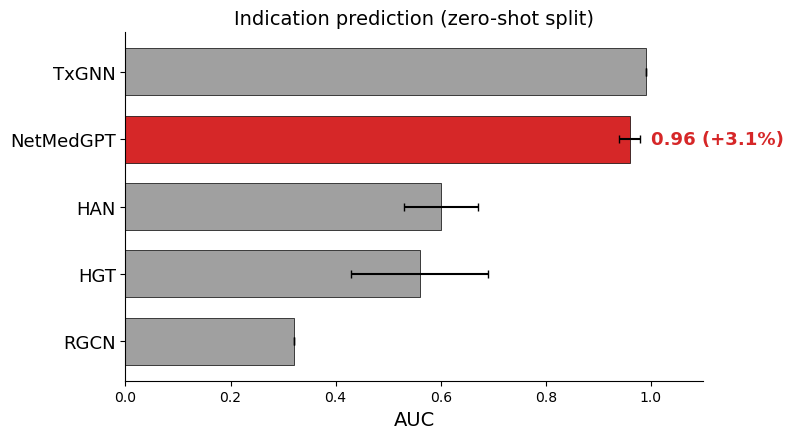

In [70]:
# plot AUC-indication: adrenal_gland
methods = ["RGCN", "HGT", "HAN","TxGNN", "NetMedGPT"]

means = []
stds = []
for i in methods:
    means.append(round(indication_aucs_adrenal_gland.loc[indication_aucs_adrenal_gland['method'] == i, 'mean'].item(), 2))
    stds.append(round(indication_aucs_adrenal_gland.loc[indication_aucs_adrenal_gland['method'] == i, 'std'].item(), 2))


# Sort by performance
data = sorted(zip(means, stds, methods), reverse=True)
means, stds, methods = zip(*data)

# Compute % improvement over best baseline (excluding BioMedFormer)
baseline_max = max(means[1:])
improvement = round((means[0] - baseline_max) / baseline_max * 100, 1)

# Colors: BioMedFormer = red, others = grey
colors = ['#D62728' if method == "NetMedGPT" else '#A0A0A0' for method in methods]

# Plot
# Define a consistent per-bar vertical space
bar_height = 0.7
vertical_padding = 1.0  # For title/labels

# Dynamically scale figure height based on number of bars
fig_height = len(methods) * bar_height + vertical_padding

fig, ax = plt.subplots(figsize=(8, fig_height))


y_pos = np.arange(len(methods))

bars = ax.barh(y_pos, means, xerr=stds, color=colors,
               capsize=3, edgecolor='black', linewidth=0.5, height=0.7)

# Reference line for best baseline
# ax.axvline(x=baseline_max, color='gray', linestyle='--', linewidth=1)
# ax.text(baseline_max + 0.01, -0.7, f"Best baseline ({baseline_max:.2f})", fontsize=12, color='gray')

# Annotate BioMedFormer
for i, (bar, method, val) in enumerate(zip(bars, methods, means)):
    if method == "NetMedGPT":
        ax.text(val + 0.04, bar.get_y() + bar.get_height() / 2,
                f"{val:.2f} (+{improvement}%)", va='center', fontsize=13, fontweight='bold', color='#D62728')

# Formatting
ax.set_yticks(y_pos)
ax.set_yticklabels(methods, fontsize=13)
ax.invert_yaxis()
ax.set_xlim(0, 1.1)
ax.set_xlabel("AUC", fontsize=14)
ax.set_title("Indication prediction (zero-shot split)", fontsize=14)

# Clean borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)

# Save
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, "netmedgpt_indication_adrenal_gland_AUC.png"), dpi=300, bbox_inches="tight")
plt.show()

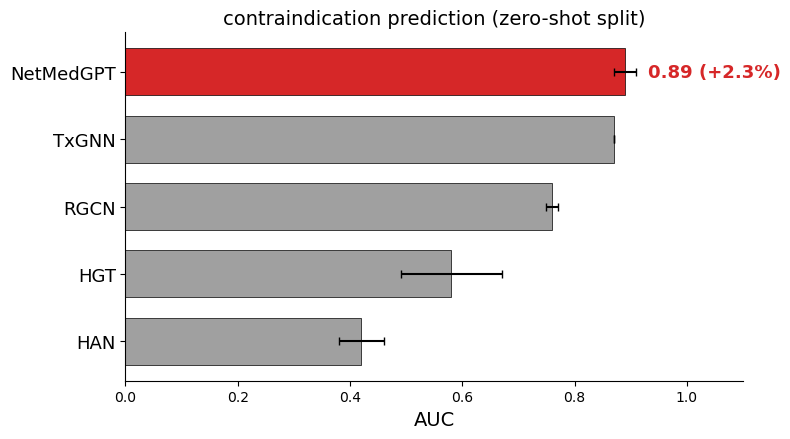

In [104]:
# plot AUC-contraindication: adrenal_gland
methods = ["RGCN", "HGT", "HAN","TxGNN", "NetMedGPT"]

means = []
stds = []
for i in methods:
    means.append(round(contraindication_aucs_adrenal_gland.loc[contraindication_aucs_adrenal_gland['method'] == i, 'mean'].item(), 2))
    stds.append(round(contraindication_aucs_adrenal_gland.loc[contraindication_aucs_adrenal_gland['method'] == i, 'std'].item(), 2))


# Sort by performance
data = sorted(zip(means, stds, methods), reverse=True)
means, stds, methods = zip(*data)

# Compute % improvement over best baseline (excluding BioMedFormer)
baseline_max = max(means[1:])
improvement = round((means[0] - baseline_max) / baseline_max * 100, 1)

# Colors: BioMedFormer = red, others = grey
colors = ['#D62728' if method == "NetMedGPT" else '#A0A0A0' for method in methods]

# Plot
# Define a consistent per-bar vertical space
bar_height = 0.7
vertical_padding = 1.0  # For title/labels

# Dynamically scale figure height based on number of bars
fig_height = len(methods) * bar_height + vertical_padding

fig, ax = plt.subplots(figsize=(8, fig_height))


y_pos = np.arange(len(methods))

bars = ax.barh(y_pos, means, xerr=stds, color=colors,
               capsize=3, edgecolor='black', linewidth=0.5, height=0.7)

# Reference line for best baseline
# ax.axvline(x=baseline_max, color='gray', linestyle='--', linewidth=1)
# ax.text(baseline_max + 0.01, -0.7, f"Best baseline ({baseline_max:.2f})", fontsize=12, color='gray')

# Annotate BioMedFormer
for i, (bar, method, val) in enumerate(zip(bars, methods, means)):
    if method == "NetMedGPT":
        ax.text(val + 0.04, bar.get_y() + bar.get_height() / 2,
                f"{val:.2f} (+{improvement}%)", va='center', fontsize=13, fontweight='bold', color='#D62728')

# Formatting
ax.set_yticks(y_pos)
ax.set_yticklabels(methods, fontsize=13)
ax.invert_yaxis()
ax.set_xlim(0, 1.1)
ax.set_xlabel("AUC", fontsize=14)
ax.set_title("contraindication prediction (zero-shot split)", fontsize=14)

# Clean borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)

# Save
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, "netmedgpt_contraindication_adrenal_gland_AUC.png"), dpi=300, bbox_inches="tight")
plt.show()

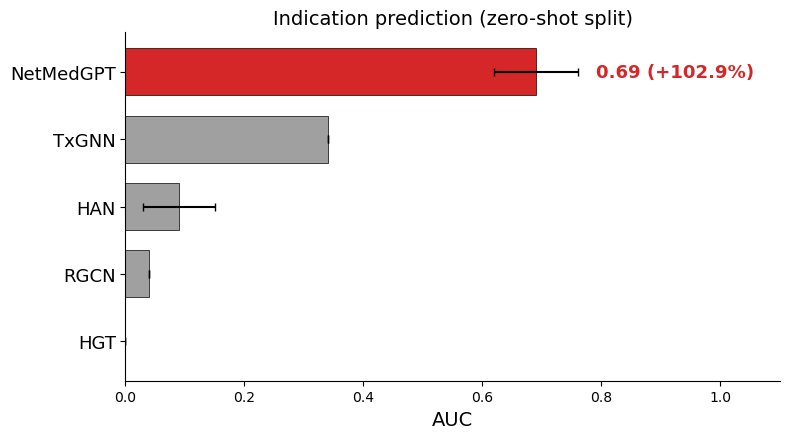

In [71]:
# plot Recall@100-indication: autoimmune
methods = ["RGCN", "HGT", "HAN","TxGNN", "NetMedGPT"]

means = []
stds = []
for i in methods:
    means.append(round(indication_recall100_autoimmune.loc[indication_recall100_autoimmune['method'] == i, 'mean'].item(), 2))
    stds.append(round(indication_recall100_autoimmune.loc[indication_recall100_autoimmune['method'] == i, 'std'].item(), 2))


# Sort by performance
data = sorted(zip(means, stds, methods), reverse=True)
means, stds, methods = zip(*data)

# Compute % improvement over best baseline (excluding BioMedFormer)
baseline_max = max(means[1:])
improvement = round((means[0] - baseline_max) / baseline_max * 100, 1)

# Colors: BioMedFormer = red, others = grey
colors = ['#D62728' if method == "NetMedGPT" else '#A0A0A0' for method in methods]

# Plot
# Define a consistent per-bar vertical space
bar_height = 0.7
vertical_padding = 1.0  # For title/labels

# Dynamically scale figure height based on number of bars
fig_height = len(methods) * bar_height + vertical_padding

fig, ax = plt.subplots(figsize=(8, fig_height))


y_pos = np.arange(len(methods))

bars = ax.barh(y_pos, means, xerr=stds, color=colors,
               capsize=3, edgecolor='black', linewidth=0.5, height=0.7)

# Reference line for best baseline
# ax.axvline(x=baseline_max, color='gray', linestyle='--', linewidth=1)
# ax.text(baseline_max + 0.01, -0.7, f"Best baseline ({baseline_max:.2f})", fontsize=12, color='gray')

# Annotate BioMedFormer
for i, (bar, method, val) in enumerate(zip(bars, methods, means)):
    if method == "NetMedGPT":
        ax.text(val + 0.1, bar.get_y() + bar.get_height() / 2,
                f"{val:.2f} (+{improvement}%)", va='center', fontsize=13, fontweight='bold', color='#D62728')

# Formatting
ax.set_yticks(y_pos)
ax.set_yticklabels(methods, fontsize=13)
ax.invert_yaxis()
ax.set_xlim(0, 1.1)
ax.set_xlabel("AUC", fontsize=14)
ax.set_title("Indication prediction (zero-shot split)", fontsize=14)

# Clean borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)

# Save
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, "netmedgpt_indication_autoimmune_recall100.png"), dpi=300, bbox_inches="tight")
plt.show()

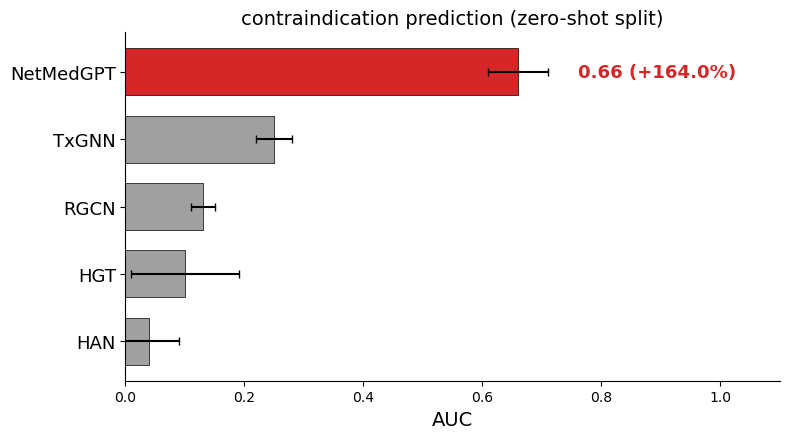

In [105]:
# plot Recall@100-contraindication: autoimmune
methods = ["RGCN", "HGT", "HAN","TxGNN", "NetMedGPT"]

means = []
stds = []
for i in methods:
    means.append(round(contraindication_recall100_autoimmune.loc[contraindication_recall100_autoimmune['method'] == i, 'mean'].item(), 2))
    stds.append(round(contraindication_recall100_autoimmune.loc[contraindication_recall100_autoimmune['method'] == i, 'std'].item(), 2))


# Sort by performance
data = sorted(zip(means, stds, methods), reverse=True)
means, stds, methods = zip(*data)

# Compute % improvement over best baseline (excluding BioMedFormer)
baseline_max = max(means[1:])
improvement = round((means[0] - baseline_max) / baseline_max * 100, 1)

# Colors: BioMedFormer = red, others = grey
colors = ['#D62728' if method == "NetMedGPT" else '#A0A0A0' for method in methods]

# Plot
# Define a consistent per-bar vertical space
bar_height = 0.7
vertical_padding = 1.0  # For title/labels

# Dynamically scale figure height based on number of bars
fig_height = len(methods) * bar_height + vertical_padding

fig, ax = plt.subplots(figsize=(8, fig_height))


y_pos = np.arange(len(methods))

bars = ax.barh(y_pos, means, xerr=stds, color=colors,
               capsize=3, edgecolor='black', linewidth=0.5, height=0.7)

# Reference line for best baseline
# ax.axvline(x=baseline_max, color='gray', linestyle='--', linewidth=1)
# ax.text(baseline_max + 0.01, -0.7, f"Best baseline ({baseline_max:.2f})", fontsize=12, color='gray')

# Annotate BioMedFormer
for i, (bar, method, val) in enumerate(zip(bars, methods, means)):
    if method == "NetMedGPT":
        ax.text(val + 0.1, bar.get_y() + bar.get_height() / 2,
                f"{val:.2f} (+{improvement}%)", va='center', fontsize=13, fontweight='bold', color='#D62728')

# Formatting
ax.set_yticks(y_pos)
ax.set_yticklabels(methods, fontsize=13)
ax.invert_yaxis()
ax.set_xlim(0, 1.1)
ax.set_xlabel("AUC", fontsize=14)
ax.set_title("contraindication prediction (zero-shot split)", fontsize=14)

# Clean borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)

# Save
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, "netmedgpt_contraindication_autoimmune_recall100.png"), dpi=300, bbox_inches="tight")
plt.show()

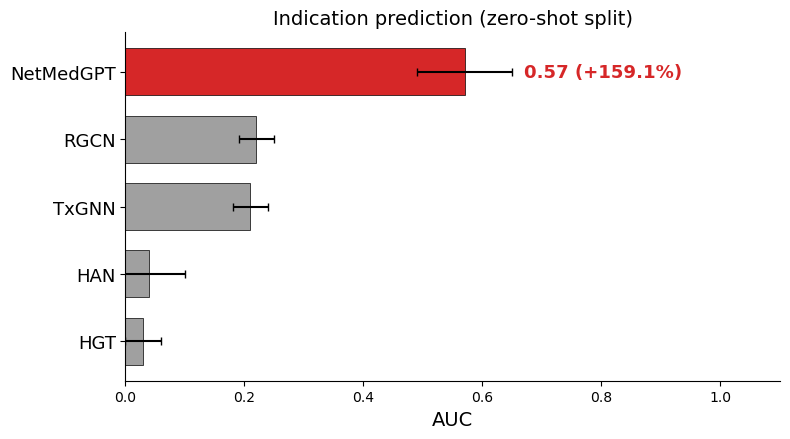

In [72]:
# plot Recall@100-indication: metabolic_disorder
methods = ["RGCN", "HGT", "HAN","TxGNN", "NetMedGPT"]

means = []
stds = []
for i in methods:
    means.append(round(indication_recall100_metabolic_disorder.loc[indication_recall100_metabolic_disorder['method'] == i, 'mean'].item(), 2))
    stds.append(round(indication_recall100_metabolic_disorder.loc[indication_recall100_metabolic_disorder['method'] == i, 'std'].item(), 2))


# Sort by performance
data = sorted(zip(means, stds, methods), reverse=True)
means, stds, methods = zip(*data)

# Compute % improvement over best baseline (excluding BioMedFormer)
baseline_max = max(means[1:])
improvement = round((means[0] - baseline_max) / baseline_max * 100, 1)

# Colors: BioMedFormer = red, others = grey
colors = ['#D62728' if method == "NetMedGPT" else '#A0A0A0' for method in methods]

# Plot
# Define a consistent per-bar vertical space
bar_height = 0.7
vertical_padding = 1.0  # For title/labels

# Dynamically scale figure height based on number of bars
fig_height = len(methods) * bar_height + vertical_padding

fig, ax = plt.subplots(figsize=(8, fig_height))


y_pos = np.arange(len(methods))

bars = ax.barh(y_pos, means, xerr=stds, color=colors,
               capsize=3, edgecolor='black', linewidth=0.5, height=0.7)

# Reference line for best baseline
# ax.axvline(x=baseline_max, color='gray', linestyle='--', linewidth=1)
# ax.text(baseline_max + 0.01, -0.7, f"Best baseline ({baseline_max:.2f})", fontsize=12, color='gray')

# Annotate BioMedFormer
for i, (bar, method, val) in enumerate(zip(bars, methods, means)):
    if method == "NetMedGPT":
        ax.text(val + 0.1, bar.get_y() + bar.get_height() / 2,
                f"{val:.2f} (+{improvement}%)", va='center', fontsize=13, fontweight='bold', color='#D62728')

# Formatting
ax.set_yticks(y_pos)
ax.set_yticklabels(methods, fontsize=13)
ax.invert_yaxis()
ax.set_xlim(0, 1.1)
ax.set_xlabel("AUC", fontsize=14)
ax.set_title("Indication prediction (zero-shot split)", fontsize=14)

# Clean borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)

# Save
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, "netmedgpt_indication_metabolic_disorder_recall100.png"), dpi=300, bbox_inches="tight")
plt.show()

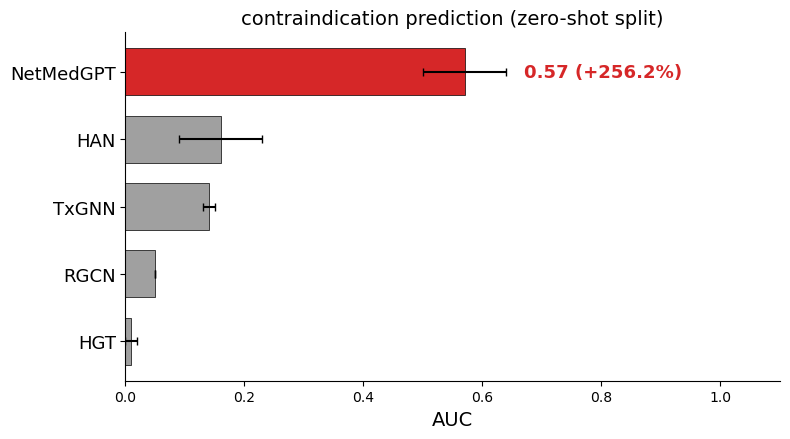

In [106]:
# plot Recall@100-contraindication: metabolic_disorder
methods = ["RGCN", "HGT", "HAN","TxGNN", "NetMedGPT"]

means = []
stds = []
for i in methods:
    means.append(round(contraindication_recall100_metabolic_disorder.loc[contraindication_recall100_metabolic_disorder['method'] == i, 'mean'].item(), 2))
    stds.append(round(contraindication_recall100_metabolic_disorder.loc[contraindication_recall100_metabolic_disorder['method'] == i, 'std'].item(), 2))


# Sort by performance
data = sorted(zip(means, stds, methods), reverse=True)
means, stds, methods = zip(*data)

# Compute % improvement over best baseline (excluding BioMedFormer)
baseline_max = max(means[1:])
improvement = round((means[0] - baseline_max) / baseline_max * 100, 1)

# Colors: BioMedFormer = red, others = grey
colors = ['#D62728' if method == "NetMedGPT" else '#A0A0A0' for method in methods]

# Plot
# Define a consistent per-bar vertical space
bar_height = 0.7
vertical_padding = 1.0  # For title/labels

# Dynamically scale figure height based on number of bars
fig_height = len(methods) * bar_height + vertical_padding

fig, ax = plt.subplots(figsize=(8, fig_height))


y_pos = np.arange(len(methods))

bars = ax.barh(y_pos, means, xerr=stds, color=colors,
               capsize=3, edgecolor='black', linewidth=0.5, height=0.7)

# Reference line for best baseline
# ax.axvline(x=baseline_max, color='gray', linestyle='--', linewidth=1)
# ax.text(baseline_max + 0.01, -0.7, f"Best baseline ({baseline_max:.2f})", fontsize=12, color='gray')

# Annotate BioMedFormer
for i, (bar, method, val) in enumerate(zip(bars, methods, means)):
    if method == "NetMedGPT":
        ax.text(val + 0.1, bar.get_y() + bar.get_height() / 2,
                f"{val:.2f} (+{improvement}%)", va='center', fontsize=13, fontweight='bold', color='#D62728')

# Formatting
ax.set_yticks(y_pos)
ax.set_yticklabels(methods, fontsize=13)
ax.invert_yaxis()
ax.set_xlim(0, 1.1)
ax.set_xlabel("AUC", fontsize=14)
ax.set_title("contraindication prediction (zero-shot split)", fontsize=14)

# Clean borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)

# Save
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, "netmedgpt_contraindication_metabolic_disorder_recall100.png"), dpi=300, bbox_inches="tight")
plt.show()

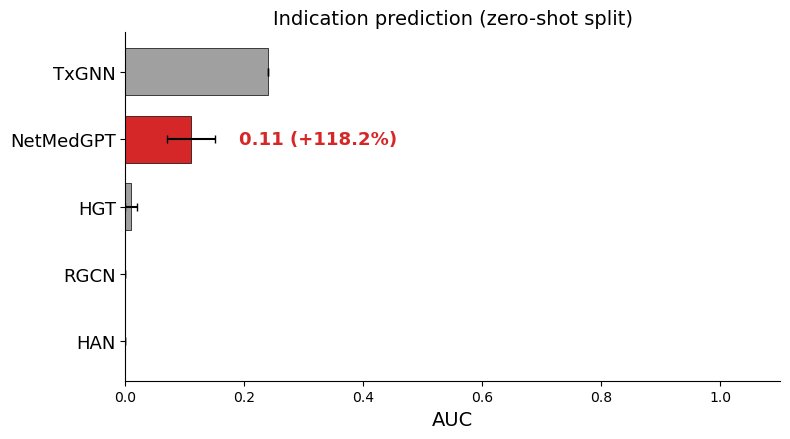

In [73]:
# plot Recall@100-indication: diabetes
methods = ["RGCN", "HGT", "HAN","TxGNN", "NetMedGPT"]

means = []
stds = []
for i in methods:
    means.append(round(indication_recall100_diabetes.loc[indication_recall100_diabetes['method'] == i, 'mean'].item(), 2))
    stds.append(round(indication_recall100_diabetes.loc[indication_recall100_diabetes['method'] == i, 'std'].item(), 2))


# Sort by performance
data = sorted(zip(means, stds, methods), reverse=True)
means, stds, methods = zip(*data)

# Compute % improvement over best baseline (excluding BioMedFormer)
baseline_max = max(means[1:])
improvement = round((means[0] - baseline_max) / baseline_max * 100, 1)

# Colors: BioMedFormer = red, others = grey
colors = ['#D62728' if method == "NetMedGPT" else '#A0A0A0' for method in methods]

# Plot
# Define a consistent per-bar vertical space
bar_height = 0.7
vertical_padding = 1.0  # For title/labels

# Dynamically scale figure height based on number of bars
fig_height = len(methods) * bar_height + vertical_padding

fig, ax = plt.subplots(figsize=(8, fig_height))


y_pos = np.arange(len(methods))

bars = ax.barh(y_pos, means, xerr=stds, color=colors,
               capsize=3, edgecolor='black', linewidth=0.5, height=0.7)

# Reference line for best baseline
# ax.axvline(x=baseline_max, color='gray', linestyle='--', linewidth=1)
# ax.text(baseline_max + 0.01, -0.7, f"Best baseline ({baseline_max:.2f})", fontsize=12, color='gray')

# Annotate BioMedFormer
for i, (bar, method, val) in enumerate(zip(bars, methods, means)):
    if method == "NetMedGPT":
        ax.text(val + 0.08, bar.get_y() + bar.get_height() / 2,
                f"{val:.2f} (+{improvement}%)", va='center', fontsize=13, fontweight='bold', color='#D62728')

# Formatting
ax.set_yticks(y_pos)
ax.set_yticklabels(methods, fontsize=13)
ax.invert_yaxis()
ax.set_xlim(0, 1.1)
ax.set_xlabel("AUC", fontsize=14)
ax.set_title("Indication prediction (zero-shot split)", fontsize=14)

# Clean borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)

# Save
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, "netmedgpt_indication_diabetes_recall100.png"), dpi=300, bbox_inches="tight")
plt.show()

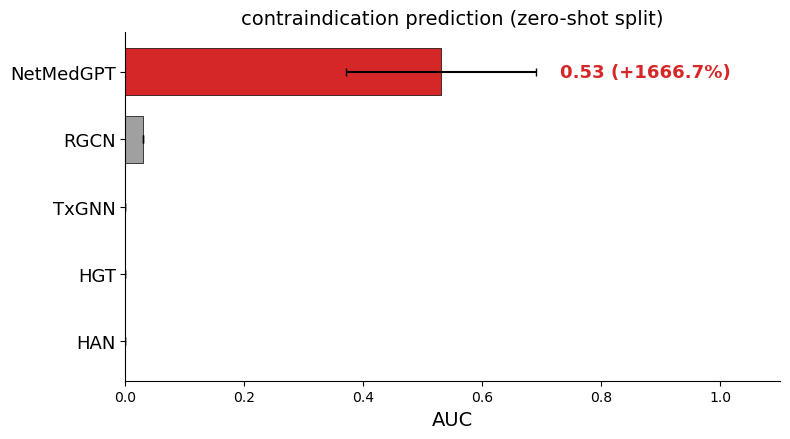

In [108]:
# plot Recall@100-contraindication: diabetes
methods = ["RGCN", "HGT", "HAN","TxGNN", "NetMedGPT"]

means = []
stds = []
for i in methods:
    means.append(round(contraindication_recall100_diabetes.loc[contraindication_recall100_diabetes['method'] == i, 'mean'].item(), 2))
    stds.append(round(contraindication_recall100_diabetes.loc[contraindication_recall100_diabetes['method'] == i, 'std'].item(), 2))


# Sort by performance
data = sorted(zip(means, stds, methods), reverse=True)
means, stds, methods = zip(*data)

# Compute % improvement over best baseline (excluding BioMedFormer)
baseline_max = max(means[1:])
improvement = round((means[0] - baseline_max) / baseline_max * 100, 1)

# Colors: BioMedFormer = red, others = grey
colors = ['#D62728' if method == "NetMedGPT" else '#A0A0A0' for method in methods]

# Plot
# Define a consistent per-bar vertical space
bar_height = 0.7
vertical_padding = 1.0  # For title/labels

# Dynamically scale figure height based on number of bars
fig_height = len(methods) * bar_height + vertical_padding

fig, ax = plt.subplots(figsize=(8, fig_height))


y_pos = np.arange(len(methods))

bars = ax.barh(y_pos, means, xerr=stds, color=colors,
               capsize=3, edgecolor='black', linewidth=0.5, height=0.7)

# Reference line for best baseline
# ax.axvline(x=baseline_max, color='gray', linestyle='--', linewidth=1)
# ax.text(baseline_max + 0.01, -0.7, f"Best baseline ({baseline_max:.2f})", fontsize=12, color='gray')

# Annotate BioMedFormer
for i, (bar, method, val) in enumerate(zip(bars, methods, means)):
    if method == "NetMedGPT":
        ax.text(val + 0.2, bar.get_y() + bar.get_height() / 2,
                f"{val:.2f} (+{improvement}%)", va='center', fontsize=13, fontweight='bold', color='#D62728')

# Formatting
ax.set_yticks(y_pos)
ax.set_yticklabels(methods, fontsize=13)
ax.invert_yaxis()
ax.set_xlim(0, 1.1)
ax.set_xlabel("AUC", fontsize=14)
ax.set_title("contraindication prediction (zero-shot split)", fontsize=14)

# Clean borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)

# Save
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, "netmedgpt_contraindication_diabetes_recall100.png"), dpi=300, bbox_inches="tight")
plt.show()

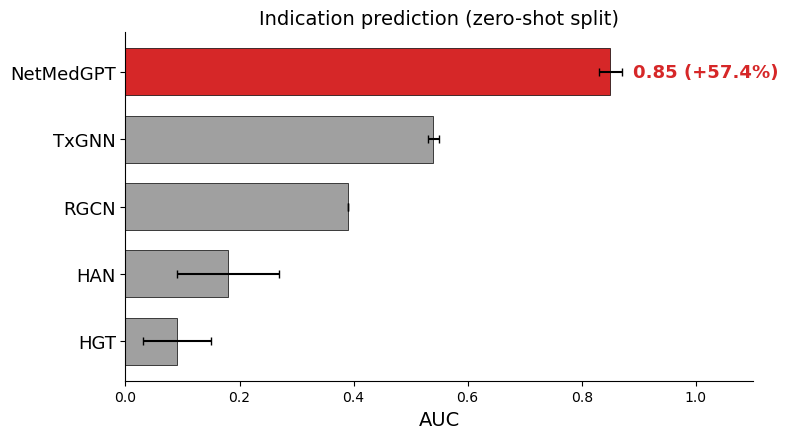

In [74]:
# plot Recall@100-indication: neurodigenerative
methods = ["RGCN", "HGT", "HAN","TxGNN", "NetMedGPT"]

means = []
stds = []
for i in methods:
    means.append(round(indication_recall100_neurodigenerative.loc[indication_recall100_neurodigenerative['method'] == i, 'mean'].item(), 2))
    stds.append(round(indication_recall100_neurodigenerative.loc[indication_recall100_neurodigenerative['method'] == i, 'std'].item(), 2))


# Sort by performance
data = sorted(zip(means, stds, methods), reverse=True)
means, stds, methods = zip(*data)

# Compute % improvement over best baseline (excluding BioMedFormer)
baseline_max = max(means[1:])
improvement = round((means[0] - baseline_max) / baseline_max * 100, 1)

# Colors: BioMedFormer = red, others = grey
colors = ['#D62728' if method == "NetMedGPT" else '#A0A0A0' for method in methods]

# Plot
# Define a consistent per-bar vertical space
bar_height = 0.7
vertical_padding = 1.0  # For title/labels

# Dynamically scale figure height based on number of bars
fig_height = len(methods) * bar_height + vertical_padding

fig, ax = plt.subplots(figsize=(8, fig_height))


y_pos = np.arange(len(methods))

bars = ax.barh(y_pos, means, xerr=stds, color=colors,
               capsize=3, edgecolor='black', linewidth=0.5, height=0.7)

# Reference line for best baseline
# ax.axvline(x=baseline_max, color='gray', linestyle='--', linewidth=1)
# ax.text(baseline_max + 0.01, -0.7, f"Best baseline ({baseline_max:.2f})", fontsize=12, color='gray')

# Annotate BioMedFormer
for i, (bar, method, val) in enumerate(zip(bars, methods, means)):
    if method == "NetMedGPT":
        ax.text(val + 0.04, bar.get_y() + bar.get_height() / 2,
                f"{val:.2f} (+{improvement}%)", va='center', fontsize=13, fontweight='bold', color='#D62728')

# Formatting
ax.set_yticks(y_pos)
ax.set_yticklabels(methods, fontsize=13)
ax.invert_yaxis()
ax.set_xlim(0, 1.1)
ax.set_xlabel("AUC", fontsize=14)
ax.set_title("Indication prediction (zero-shot split)", fontsize=14)

# Clean borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)

# Save
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, "netmedgpt_indication_neurodigenerative_recall100.png"), dpi=300, bbox_inches="tight")
plt.show()

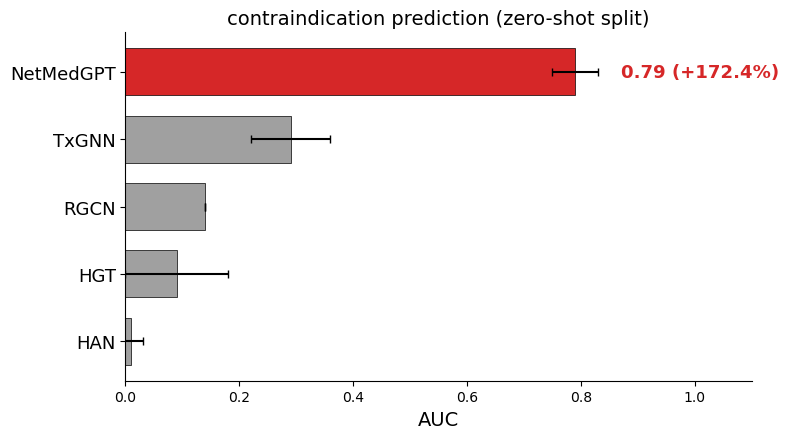

In [110]:
# plot Recall@100-contraindication: neurodigenerative
methods = ["RGCN", "HGT", "HAN","TxGNN", "NetMedGPT"]

means = []
stds = []
for i in methods:
    means.append(round(contraindication_recall100_neurodigenerative.loc[contraindication_recall100_neurodigenerative['method'] == i, 'mean'].item(), 2))
    stds.append(round(contraindication_recall100_neurodigenerative.loc[contraindication_recall100_neurodigenerative['method'] == i, 'std'].item(), 2))


# Sort by performance
data = sorted(zip(means, stds, methods), reverse=True)
means, stds, methods = zip(*data)

# Compute % improvement over best baseline (excluding BioMedFormer)
baseline_max = max(means[1:])
improvement = round((means[0] - baseline_max) / baseline_max * 100, 1)

# Colors: BioMedFormer = red, others = grey
colors = ['#D62728' if method == "NetMedGPT" else '#A0A0A0' for method in methods]

# Plot
# Define a consistent per-bar vertical space
bar_height = 0.7
vertical_padding = 1.0  # For title/labels

# Dynamically scale figure height based on number of bars
fig_height = len(methods) * bar_height + vertical_padding

fig, ax = plt.subplots(figsize=(8, fig_height))


y_pos = np.arange(len(methods))

bars = ax.barh(y_pos, means, xerr=stds, color=colors,
               capsize=3, edgecolor='black', linewidth=0.5, height=0.7)

# Reference line for best baseline
# ax.axvline(x=baseline_max, color='gray', linestyle='--', linewidth=1)
# ax.text(baseline_max + 0.01, -0.7, f"Best baseline ({baseline_max:.2f})", fontsize=12, color='gray')

# Annotate BioMedFormer
for i, (bar, method, val) in enumerate(zip(bars, methods, means)):
    if method == "NetMedGPT":
        ax.text(val + 0.08, bar.get_y() + bar.get_height() / 2,
                f"{val:.2f} (+{improvement}%)", va='center', fontsize=13, fontweight='bold', color='#D62728')

# Formatting
ax.set_yticks(y_pos)
ax.set_yticklabels(methods, fontsize=13)
ax.invert_yaxis()
ax.set_xlim(0, 1.1)
ax.set_xlabel("AUC", fontsize=14)
ax.set_title("contraindication prediction (zero-shot split)", fontsize=14)

# Clean borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)

# Save
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, "netmedgpt_contraindication_neurodigenerative_recall100.png"), dpi=300, bbox_inches="tight")
plt.show()

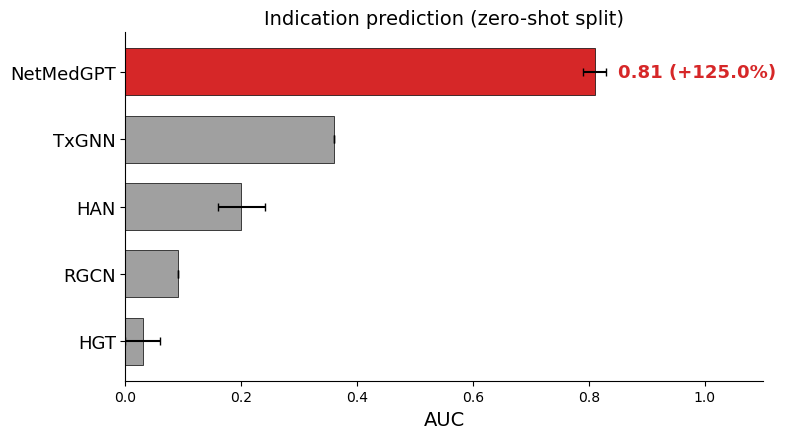

In [75]:
# plot Recall@100-indication: cell_proliferation
methods = ["RGCN", "HGT", "HAN","TxGNN", "NetMedGPT"]

means = []
stds = []
for i in methods:
    means.append(round(indication_recall100_cell_proliferation.loc[indication_recall100_cell_proliferation['method'] == i, 'mean'].item(), 2))
    stds.append(round(indication_recall100_cell_proliferation.loc[indication_recall100_cell_proliferation['method'] == i, 'std'].item(), 2))


# Sort by performance
data = sorted(zip(means, stds, methods), reverse=True)
means, stds, methods = zip(*data)

# Compute % improvement over best baseline (excluding BioMedFormer)
baseline_max = max(means[1:])
improvement = round((means[0] - baseline_max) / baseline_max * 100, 1)

# Colors: BioMedFormer = red, others = grey
colors = ['#D62728' if method == "NetMedGPT" else '#A0A0A0' for method in methods]

# Plot
# Define a consistent per-bar vertical space
bar_height = 0.7
vertical_padding = 1.0  # For title/labels

# Dynamically scale figure height based on number of bars
fig_height = len(methods) * bar_height + vertical_padding

fig, ax = plt.subplots(figsize=(8, fig_height))


y_pos = np.arange(len(methods))

bars = ax.barh(y_pos, means, xerr=stds, color=colors,
               capsize=3, edgecolor='black', linewidth=0.5, height=0.7)

# Reference line for best baseline
# ax.axvline(x=baseline_max, color='gray', linestyle='--', linewidth=1)
# ax.text(baseline_max + 0.01, -0.7, f"Best baseline ({baseline_max:.2f})", fontsize=12, color='gray')

# Annotate BioMedFormer
for i, (bar, method, val) in enumerate(zip(bars, methods, means)):
    if method == "NetMedGPT":
        ax.text(val + 0.04, bar.get_y() + bar.get_height() / 2,
                f"{val:.2f} (+{improvement}%)", va='center', fontsize=13, fontweight='bold', color='#D62728')

# Formatting
ax.set_yticks(y_pos)
ax.set_yticklabels(methods, fontsize=13)
ax.invert_yaxis()
ax.set_xlim(0, 1.1)
ax.set_xlabel("AUC", fontsize=14)
ax.set_title("Indication prediction (zero-shot split)", fontsize=14)

# Clean borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)

# Save
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, "netmedgpt_indication_cell_proliferation_recall100.png"), dpi=300, bbox_inches="tight")
plt.show()

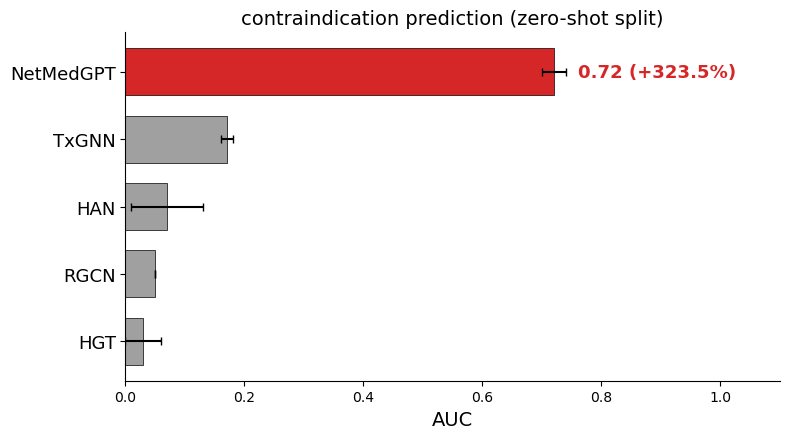

In [111]:
# plot Recall@100-contraindication: cell_proliferation
methods = ["RGCN", "HGT", "HAN","TxGNN", "NetMedGPT"]

means = []
stds = []
for i in methods:
    means.append(round(contraindication_recall100_cell_proliferation.loc[contraindication_recall100_cell_proliferation['method'] == i, 'mean'].item(), 2))
    stds.append(round(contraindication_recall100_cell_proliferation.loc[contraindication_recall100_cell_proliferation['method'] == i, 'std'].item(), 2))


# Sort by performance
data = sorted(zip(means, stds, methods), reverse=True)
means, stds, methods = zip(*data)

# Compute % improvement over best baseline (excluding BioMedFormer)
baseline_max = max(means[1:])
improvement = round((means[0] - baseline_max) / baseline_max * 100, 1)

# Colors: BioMedFormer = red, others = grey
colors = ['#D62728' if method == "NetMedGPT" else '#A0A0A0' for method in methods]

# Plot
# Define a consistent per-bar vertical space
bar_height = 0.7
vertical_padding = 1.0  # For title/labels

# Dynamically scale figure height based on number of bars
fig_height = len(methods) * bar_height + vertical_padding

fig, ax = plt.subplots(figsize=(8, fig_height))


y_pos = np.arange(len(methods))

bars = ax.barh(y_pos, means, xerr=stds, color=colors,
               capsize=3, edgecolor='black', linewidth=0.5, height=0.7)

# Reference line for best baseline
# ax.axvline(x=baseline_max, color='gray', linestyle='--', linewidth=1)
# ax.text(baseline_max + 0.01, -0.7, f"Best baseline ({baseline_max:.2f})", fontsize=12, color='gray')

# Annotate BioMedFormer
for i, (bar, method, val) in enumerate(zip(bars, methods, means)):
    if method == "NetMedGPT":
        ax.text(val + 0.04, bar.get_y() + bar.get_height() / 2,
                f"{val:.2f} (+{improvement}%)", va='center', fontsize=13, fontweight='bold', color='#D62728')

# Formatting
ax.set_yticks(y_pos)
ax.set_yticklabels(methods, fontsize=13)
ax.invert_yaxis()
ax.set_xlim(0, 1.1)
ax.set_xlabel("AUC", fontsize=14)
ax.set_title("contraindication prediction (zero-shot split)", fontsize=14)

# Clean borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)

# Save
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, "netmedgpt_contraindication_cell_proliferation_recall100.png"), dpi=300, bbox_inches="tight")
plt.show()

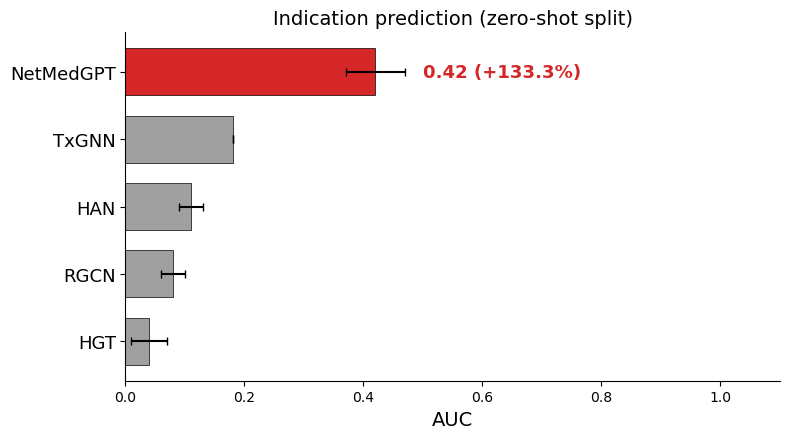

In [76]:
# plot Recall@100-indication: mental_health
methods = ["RGCN", "HGT", "HAN","TxGNN", "NetMedGPT"]

means = []
stds = []
for i in methods:
    means.append(round(indication_recall100_mental_health.loc[indication_recall100_mental_health['method'] == i, 'mean'].item(), 2))
    stds.append(round(indication_recall100_mental_health.loc[indication_recall100_mental_health['method'] == i, 'std'].item(), 2))


# Sort by performance
data = sorted(zip(means, stds, methods), reverse=True)
means, stds, methods = zip(*data)

# Compute % improvement over best baseline (excluding BioMedFormer)
baseline_max = max(means[1:])
improvement = round((means[0] - baseline_max) / baseline_max * 100, 1)

# Colors: BioMedFormer = red, others = grey
colors = ['#D62728' if method == "NetMedGPT" else '#A0A0A0' for method in methods]

# Plot
# Define a consistent per-bar vertical space
bar_height = 0.7
vertical_padding = 1.0  # For title/labels

# Dynamically scale figure height based on number of bars
fig_height = len(methods) * bar_height + vertical_padding

fig, ax = plt.subplots(figsize=(8, fig_height))


y_pos = np.arange(len(methods))

bars = ax.barh(y_pos, means, xerr=stds, color=colors,
               capsize=3, edgecolor='black', linewidth=0.5, height=0.7)

# Reference line for best baseline
# ax.axvline(x=baseline_max, color='gray', linestyle='--', linewidth=1)
# ax.text(baseline_max + 0.01, -0.7, f"Best baseline ({baseline_max:.2f})", fontsize=12, color='gray')

# Annotate BioMedFormer
for i, (bar, method, val) in enumerate(zip(bars, methods, means)):
    if method == "NetMedGPT":
        ax.text(val + 0.08, bar.get_y() + bar.get_height() / 2,
                f"{val:.2f} (+{improvement}%)", va='center', fontsize=13, fontweight='bold', color='#D62728')

# Formatting
ax.set_yticks(y_pos)
ax.set_yticklabels(methods, fontsize=13)
ax.invert_yaxis()
ax.set_xlim(0, 1.1)
ax.set_xlabel("AUC", fontsize=14)
ax.set_title("Indication prediction (zero-shot split)", fontsize=14)

# Clean borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)

# Save
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, "netmedgpt_indication_mental_health_recall100.png"), dpi=300, bbox_inches="tight")
plt.show()

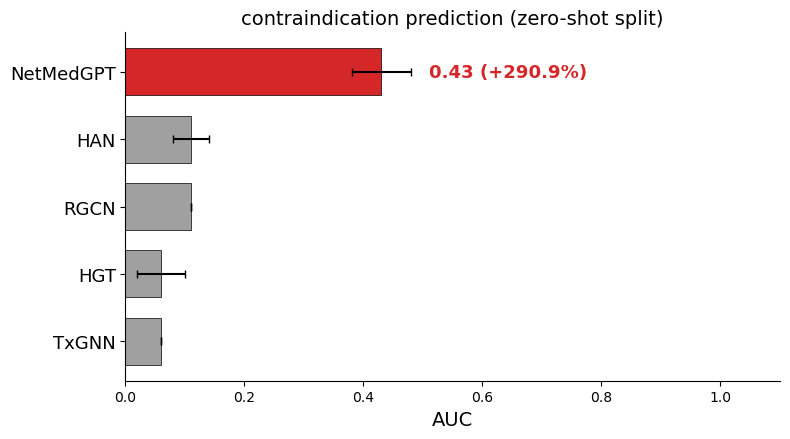

In [112]:
# plot Recall@100-contraindication: mental_health
methods = ["RGCN", "HGT", "HAN","TxGNN", "NetMedGPT"]

means = []
stds = []
for i in methods:
    means.append(round(contraindication_recall100_mental_health.loc[contraindication_recall100_mental_health['method'] == i, 'mean'].item(), 2))
    stds.append(round(contraindication_recall100_mental_health.loc[contraindication_recall100_mental_health['method'] == i, 'std'].item(), 2))


# Sort by performance
data = sorted(zip(means, stds, methods), reverse=True)
means, stds, methods = zip(*data)

# Compute % improvement over best baseline (excluding BioMedFormer)
baseline_max = max(means[1:])
improvement = round((means[0] - baseline_max) / baseline_max * 100, 1)

# Colors: BioMedFormer = red, others = grey
colors = ['#D62728' if method == "NetMedGPT" else '#A0A0A0' for method in methods]

# Plot
# Define a consistent per-bar vertical space
bar_height = 0.7
vertical_padding = 1.0  # For title/labels

# Dynamically scale figure height based on number of bars
fig_height = len(methods) * bar_height + vertical_padding

fig, ax = plt.subplots(figsize=(8, fig_height))


y_pos = np.arange(len(methods))

bars = ax.barh(y_pos, means, xerr=stds, color=colors,
               capsize=3, edgecolor='black', linewidth=0.5, height=0.7)

# Reference line for best baseline
# ax.axvline(x=baseline_max, color='gray', linestyle='--', linewidth=1)
# ax.text(baseline_max + 0.01, -0.7, f"Best baseline ({baseline_max:.2f})", fontsize=12, color='gray')

# Annotate BioMedFormer
for i, (bar, method, val) in enumerate(zip(bars, methods, means)):
    if method == "NetMedGPT":
        ax.text(val + 0.08, bar.get_y() + bar.get_height() / 2,
                f"{val:.2f} (+{improvement}%)", va='center', fontsize=13, fontweight='bold', color='#D62728')

# Formatting
ax.set_yticks(y_pos)
ax.set_yticklabels(methods, fontsize=13)
ax.invert_yaxis()
ax.set_xlim(0, 1.1)
ax.set_xlabel("AUC", fontsize=14)
ax.set_title("contraindication prediction (zero-shot split)", fontsize=14)

# Clean borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)

# Save
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, "netmedgpt_contraindication_mental_health_recall100.png"), dpi=300, bbox_inches="tight")
plt.show()

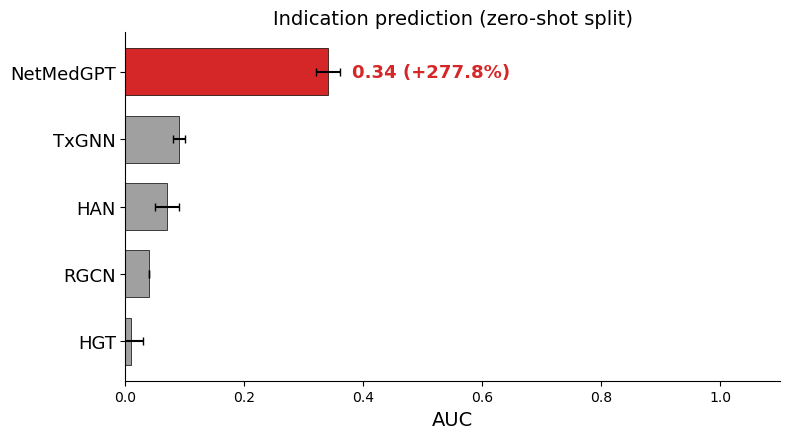

In [77]:
# plot Recall@100-indication:cardiovascular
methods = ["RGCN", "HGT", "HAN","TxGNN", "NetMedGPT"]

means = []
stds = []
for i in methods:
    means.append(round(indication_recall100_cardiovascular.loc[indication_recall100_cardiovascular['method'] == i, 'mean'].item(), 2))
    stds.append(round(indication_recall100_cardiovascular.loc[indication_recall100_cardiovascular['method'] == i, 'std'].item(), 2))


# Sort by performance
data = sorted(zip(means, stds, methods), reverse=True)
means, stds, methods = zip(*data)

# Compute % improvement over best baseline (excluding BioMedFormer)
baseline_max = max(means[1:])
improvement = round((means[0] - baseline_max) / baseline_max * 100, 1)

# Colors: BioMedFormer = red, others = grey
colors = ['#D62728' if method == "NetMedGPT" else '#A0A0A0' for method in methods]

# Plot
# Define a consistent per-bar vertical space
bar_height = 0.7
vertical_padding = 1.0  # For title/labels

# Dynamically scale figure height based on number of bars
fig_height = len(methods) * bar_height + vertical_padding

fig, ax = plt.subplots(figsize=(8, fig_height))


y_pos = np.arange(len(methods))

bars = ax.barh(y_pos, means, xerr=stds, color=colors,
               capsize=3, edgecolor='black', linewidth=0.5, height=0.7)

# Reference line for best baseline
# ax.axvline(x=baseline_max, color='gray', linestyle='--', linewidth=1)
# ax.text(baseline_max + 0.01, -0.7, f"Best baseline ({baseline_max:.2f})", fontsize=12, color='gray')

# Annotate BioMedFormer
for i, (bar, method, val) in enumerate(zip(bars, methods, means)):
    if method == "NetMedGPT":
        ax.text(val + 0.04, bar.get_y() + bar.get_height() / 2,
                f"{val:.2f} (+{improvement}%)", va='center', fontsize=13, fontweight='bold', color='#D62728')

# Formatting
ax.set_yticks(y_pos)
ax.set_yticklabels(methods, fontsize=13)
ax.invert_yaxis()
ax.set_xlim(0, 1.1)
ax.set_xlabel("AUC", fontsize=14)
ax.set_title("Indication prediction (zero-shot split)", fontsize=14)

# Clean borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)

# Save
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, "netmedgpt_indication_cardiovascular_recall100.png"), dpi=300, bbox_inches="tight")
plt.show()

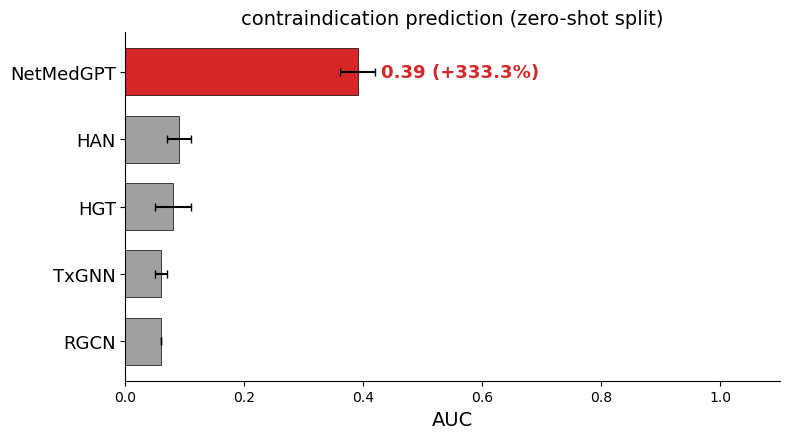

In [113]:
# plot Recall@100-contraindication:cardiovascular
methods = ["RGCN", "HGT", "HAN","TxGNN", "NetMedGPT"]

means = []
stds = []
for i in methods:
    means.append(round(contraindication_recall100_cardiovascular.loc[contraindication_recall100_cardiovascular['method'] == i, 'mean'].item(), 2))
    stds.append(round(contraindication_recall100_cardiovascular.loc[contraindication_recall100_cardiovascular['method'] == i, 'std'].item(), 2))


# Sort by performance
data = sorted(zip(means, stds, methods), reverse=True)
means, stds, methods = zip(*data)

# Compute % improvement over best baseline (excluding BioMedFormer)
baseline_max = max(means[1:])
improvement = round((means[0] - baseline_max) / baseline_max * 100, 1)

# Colors: BioMedFormer = red, others = grey
colors = ['#D62728' if method == "NetMedGPT" else '#A0A0A0' for method in methods]

# Plot
# Define a consistent per-bar vertical space
bar_height = 0.7
vertical_padding = 1.0  # For title/labels

# Dynamically scale figure height based on number of bars
fig_height = len(methods) * bar_height + vertical_padding

fig, ax = plt.subplots(figsize=(8, fig_height))


y_pos = np.arange(len(methods))

bars = ax.barh(y_pos, means, xerr=stds, color=colors,
               capsize=3, edgecolor='black', linewidth=0.5, height=0.7)

# Reference line for best baseline
# ax.axvline(x=baseline_max, color='gray', linestyle='--', linewidth=1)
# ax.text(baseline_max + 0.01, -0.7, f"Best baseline ({baseline_max:.2f})", fontsize=12, color='gray')

# Annotate BioMedFormer
for i, (bar, method, val) in enumerate(zip(bars, methods, means)):
    if method == "NetMedGPT":
        ax.text(val + 0.04, bar.get_y() + bar.get_height() / 2,
                f"{val:.2f} (+{improvement}%)", va='center', fontsize=13, fontweight='bold', color='#D62728')

# Formatting
ax.set_yticks(y_pos)
ax.set_yticklabels(methods, fontsize=13)
ax.invert_yaxis()
ax.set_xlim(0, 1.1)
ax.set_xlabel("AUC", fontsize=14)
ax.set_title("contraindication prediction (zero-shot split)", fontsize=14)

# Clean borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)

# Save
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, "netmedgpt_contraindication_cardiovascular_recall100.png"), dpi=300, bbox_inches="tight")
plt.show()

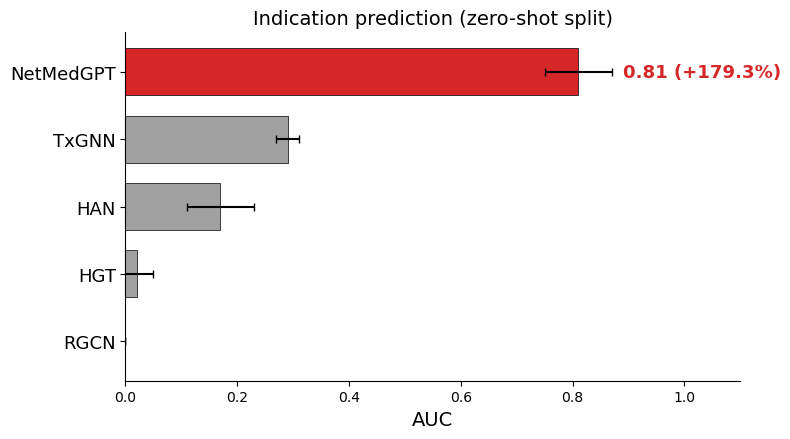

In [78]:
# plot Recall@100-indication: anemia
methods = ["RGCN", "HGT", "HAN","TxGNN", "NetMedGPT"]

means = []
stds = []
for i in methods:
    means.append(round(indication_recall100_anemia.loc[indication_recall100_anemia['method'] == i, 'mean'].item(), 2))
    stds.append(round(indication_recall100_anemia.loc[indication_recall100_anemia['method'] == i, 'std'].item(), 2))


# Sort by performance
data = sorted(zip(means, stds, methods), reverse=True)
means, stds, methods = zip(*data)

# Compute % improvement over best baseline (excluding BioMedFormer)
baseline_max = max(means[1:])
improvement = round((means[0] - baseline_max) / baseline_max * 100, 1)

# Colors: BioMedFormer = red, others = grey
colors = ['#D62728' if method == "NetMedGPT" else '#A0A0A0' for method in methods]

# Plot
# Define a consistent per-bar vertical space
bar_height = 0.7
vertical_padding = 1.0  # For title/labels

# Dynamically scale figure height based on number of bars
fig_height = len(methods) * bar_height + vertical_padding

fig, ax = plt.subplots(figsize=(8, fig_height))


y_pos = np.arange(len(methods))

bars = ax.barh(y_pos, means, xerr=stds, color=colors,
               capsize=3, edgecolor='black', linewidth=0.5, height=0.7)

# Reference line for best baseline
# ax.axvline(x=baseline_max, color='gray', linestyle='--', linewidth=1)
# ax.text(baseline_max + 0.01, -0.7, f"Best baseline ({baseline_max:.2f})", fontsize=12, color='gray')

# Annotate BioMedFormer
for i, (bar, method, val) in enumerate(zip(bars, methods, means)):
    if method == "NetMedGPT":
        ax.text(val + 0.08, bar.get_y() + bar.get_height() / 2,
                f"{val:.2f} (+{improvement}%)", va='center', fontsize=13, fontweight='bold', color='#D62728')

# Formatting
ax.set_yticks(y_pos)
ax.set_yticklabels(methods, fontsize=13)
ax.invert_yaxis()
ax.set_xlim(0, 1.1)
ax.set_xlabel("AUC", fontsize=14)
ax.set_title("Indication prediction (zero-shot split)", fontsize=14)

# Clean borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)

# Save
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, "netmedgpt_indication_anemia_recall100.png"), dpi=300, bbox_inches="tight")
plt.show()

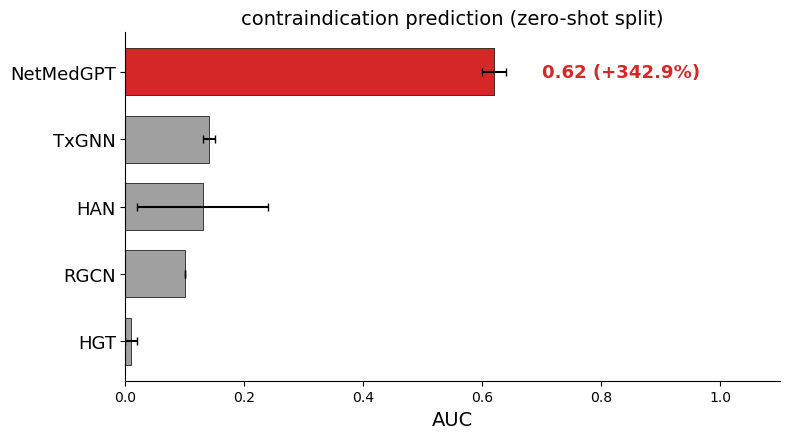

In [114]:
# plot Recall@100-contraindication: anemia
methods = ["RGCN", "HGT", "HAN","TxGNN", "NetMedGPT"]

means = []
stds = []
for i in methods:
    means.append(round(contraindication_recall100_anemia.loc[contraindication_recall100_anemia['method'] == i, 'mean'].item(), 2))
    stds.append(round(contraindication_recall100_anemia.loc[contraindication_recall100_anemia['method'] == i, 'std'].item(), 2))


# Sort by performance
data = sorted(zip(means, stds, methods), reverse=True)
means, stds, methods = zip(*data)

# Compute % improvement over best baseline (excluding BioMedFormer)
baseline_max = max(means[1:])
improvement = round((means[0] - baseline_max) / baseline_max * 100, 1)

# Colors: BioMedFormer = red, others = grey
colors = ['#D62728' if method == "NetMedGPT" else '#A0A0A0' for method in methods]

# Plot
# Define a consistent per-bar vertical space
bar_height = 0.7
vertical_padding = 1.0  # For title/labels

# Dynamically scale figure height based on number of bars
fig_height = len(methods) * bar_height + vertical_padding

fig, ax = plt.subplots(figsize=(8, fig_height))


y_pos = np.arange(len(methods))

bars = ax.barh(y_pos, means, xerr=stds, color=colors,
               capsize=3, edgecolor='black', linewidth=0.5, height=0.7)

# Reference line for best baseline
# ax.axvline(x=baseline_max, color='gray', linestyle='--', linewidth=1)
# ax.text(baseline_max + 0.01, -0.7, f"Best baseline ({baseline_max:.2f})", fontsize=12, color='gray')

# Annotate BioMedFormer
for i, (bar, method, val) in enumerate(zip(bars, methods, means)):
    if method == "NetMedGPT":
        ax.text(val + 0.08, bar.get_y() + bar.get_height() / 2,
                f"{val:.2f} (+{improvement}%)", va='center', fontsize=13, fontweight='bold', color='#D62728')

# Formatting
ax.set_yticks(y_pos)
ax.set_yticklabels(methods, fontsize=13)
ax.invert_yaxis()
ax.set_xlim(0, 1.1)
ax.set_xlabel("AUC", fontsize=14)
ax.set_title("contraindication prediction (zero-shot split)", fontsize=14)

# Clean borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)

# Save
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, "netmedgpt_contraindication_anemia_recall100.png"), dpi=300, bbox_inches="tight")
plt.show()

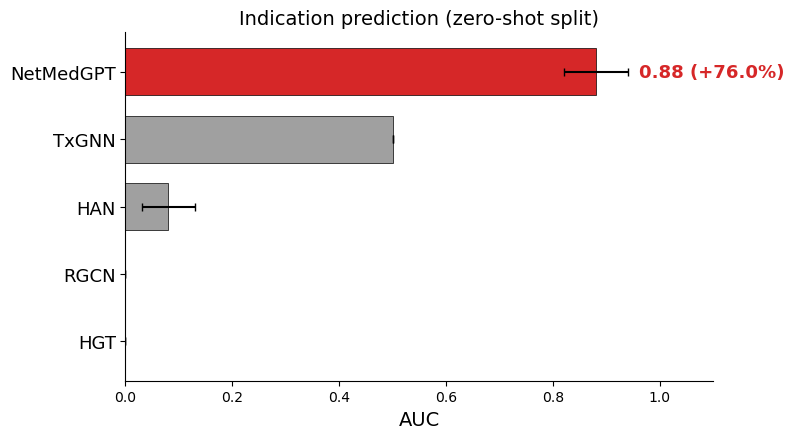

In [79]:
# plot Recall@100-indication: adrenal_gland
methods = ["RGCN", "HGT", "HAN","TxGNN", "NetMedGPT"]

means = []
stds = []
for i in methods:
    means.append(round(indication_recall100_adrenal_gland.loc[indication_recall100_adrenal_gland['method'] == i, 'mean'].item(), 2))
    stds.append(round(indication_recall100_adrenal_gland.loc[indication_recall100_adrenal_gland['method'] == i, 'std'].item(), 2))


# Sort by performance
data = sorted(zip(means, stds, methods), reverse=True)
means, stds, methods = zip(*data)

# Compute % improvement over best baseline (excluding BioMedFormer)
baseline_max = max(means[1:])
improvement = round((means[0] - baseline_max) / baseline_max * 100, 1)

# Colors: BioMedFormer = red, others = grey
colors = ['#D62728' if method == "NetMedGPT" else '#A0A0A0' for method in methods]

# Plot
# Define a consistent per-bar vertical space
bar_height = 0.7
vertical_padding = 1.0  # For title/labels

# Dynamically scale figure height based on number of bars
fig_height = len(methods) * bar_height + vertical_padding

fig, ax = plt.subplots(figsize=(8, fig_height))


y_pos = np.arange(len(methods))

bars = ax.barh(y_pos, means, xerr=stds, color=colors,
               capsize=3, edgecolor='black', linewidth=0.5, height=0.7)

# Reference line for best baseline
# ax.axvline(x=baseline_max, color='gray', linestyle='--', linewidth=1)
# ax.text(baseline_max + 0.01, -0.7, f"Best baseline ({baseline_max:.2f})", fontsize=12, color='gray')

# Annotate BioMedFormer
for i, (bar, method, val) in enumerate(zip(bars, methods, means)):
    if method == "NetMedGPT":
        ax.text(val + 0.08, bar.get_y() + bar.get_height() / 2,
                f"{val:.2f} (+{improvement}%)", va='center', fontsize=13, fontweight='bold', color='#D62728')

# Formatting
ax.set_yticks(y_pos)
ax.set_yticklabels(methods, fontsize=13)
ax.invert_yaxis()
ax.set_xlim(0, 1.1)
ax.set_xlabel("AUC", fontsize=14)
ax.set_title("Indication prediction (zero-shot split)", fontsize=14)

# Clean borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)

# Save
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, "netmedgpt_indication_adrenal_gland_recall100.png"), dpi=300, bbox_inches="tight")
plt.show()

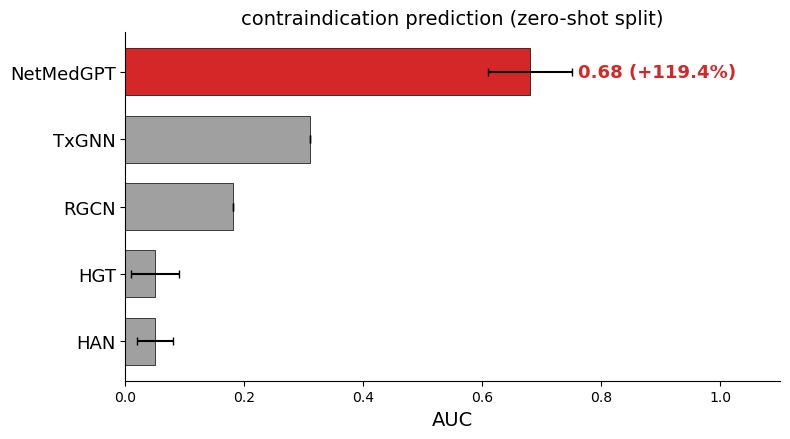

In [115]:
# plot Recall@100-contraindication: adrenal_gland
methods = ["RGCN", "HGT", "HAN","TxGNN", "NetMedGPT"]

means = []
stds = []
for i in methods:
    means.append(round(contraindication_recall100_adrenal_gland.loc[contraindication_recall100_adrenal_gland['method'] == i, 'mean'].item(), 2))
    stds.append(round(contraindication_recall100_adrenal_gland.loc[contraindication_recall100_adrenal_gland['method'] == i, 'std'].item(), 2))


# Sort by performance
data = sorted(zip(means, stds, methods), reverse=True)
means, stds, methods = zip(*data)

# Compute % improvement over best baseline (excluding BioMedFormer)
baseline_max = max(means[1:])
improvement = round((means[0] - baseline_max) / baseline_max * 100, 1)

# Colors: BioMedFormer = red, others = grey
colors = ['#D62728' if method == "NetMedGPT" else '#A0A0A0' for method in methods]

# Plot
# Define a consistent per-bar vertical space
bar_height = 0.7
vertical_padding = 1.0  # For title/labels

# Dynamically scale figure height based on number of bars
fig_height = len(methods) * bar_height + vertical_padding

fig, ax = plt.subplots(figsize=(8, fig_height))


y_pos = np.arange(len(methods))

bars = ax.barh(y_pos, means, xerr=stds, color=colors,
               capsize=3, edgecolor='black', linewidth=0.5, height=0.7)

# Reference line for best baseline
# ax.axvline(x=baseline_max, color='gray', linestyle='--', linewidth=1)
# ax.text(baseline_max + 0.01, -0.7, f"Best baseline ({baseline_max:.2f})", fontsize=12, color='gray')

# Annotate BioMedFormer
for i, (bar, method, val) in enumerate(zip(bars, methods, means)):
    if method == "NetMedGPT":
        ax.text(val + 0.08, bar.get_y() + bar.get_height() / 2,
                f"{val:.2f} (+{improvement}%)", va='center', fontsize=13, fontweight='bold', color='#D62728')

# Formatting
ax.set_yticks(y_pos)
ax.set_yticklabels(methods, fontsize=13)
ax.invert_yaxis()
ax.set_xlim(0, 1.1)
ax.set_xlabel("AUC", fontsize=14)
ax.set_title("contraindication prediction (zero-shot split)", fontsize=14)

# Clean borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)

# Save
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, "netmedgpt_contraindication_adrenal_gland_recall100.png"), dpi=300, bbox_inches="tight")
plt.show()